# What does the IH OV circuit extract from output positions?

All previous analyses measured properties of the hidden state AT output positions. But the IH doesn't copy that hidden state — it applies the OV projection (W_V @ W_O) before writing to the final position. This notebook decodes the OV output with logit lens to see what the IH actually extracts.

**Three possible outcomes:**
- OV decodes as the SAME output word ('Paris', rank 1) → IHs copy word identity
- OV decodes as OTHER outputs from same task ('Berlin', 'Madrid'...) → category-level extraction
- OV decodes as nothing interpretable → steering signal in null space of unembedding

In [1]:
import sys
sys.path.insert(0, '../..')
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import random
import pickle

from transformer_lens import HookedTransformer
from configs import *
from utils import *

random.seed(SEED)
torch.manual_seed(SEED)
%matplotlib inline

/home/cvllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-07 00:53:54.482365: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HookedTransformer.from_pretrained(
    MODEL_NAME, device=DEVICE,
    dtype=torch.float16 if DEVICE == 'cuda' else torch.float32
)
model.eval()
n_layers = model.cfg.n_layers
n_heads = model.cfg.n_heads
d_model = model.cfg.d_model

with open('../../configs/splits.pkl', 'rb') as f:
    all_splits = pickle.load(f)
tasks = load_hendel_data(HENDEL_REPO)
print(f'{n_layers}L, {n_heads}H, d={d_model}, {len(all_splits)} tasks')

`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.95it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
28L, 24H, d=3072, 20 tasks


In [3]:
# Identify output-attending heads (same selection as before)
all_prompts_sub = []
for task_name, splits in all_splits.items():
    for pdata in splits['icl_prompts'][:5]:
        all_prompts_sub.append(pdata)

_, attn_to_out, _ = extract_attention_patterns(model, all_prompts_sub)
output_attending_heads = select_top_heads(attn_to_out, percentile=90)
print(f'Output-attending heads (top 10%): {len(output_attending_heads)}')

Attention patterns: 100%|██████████| 100/100 [00:05<00:00, 18.01it/s]

Output-attending heads (top 10%): 68


In [4]:
# Helpers for OV decoding
W_U_decode = model.W_U.detach().cpu().float()  # [d_model, vocab]

def ov_matrix(model, layer, head):
    """Return W_V @ W_O for one head as a numpy [d_model, d_model] matrix."""
    W_V = model.blocks[layer].attn.W_V[head].detach().cpu().float().numpy()
    W_O = model.blocks[layer].attn.W_O[head].detach().cpu().float().numpy()
    return W_V @ W_O

def logit_lens(h_vec, model, W_U):
    """Layer norm + unembed a residual vector → logits over vocab."""
    h_t = torch.tensor(h_vec, dtype=torch.float32).unsqueeze(0).to(model.cfg.device)
    if hasattr(model, 'ln_final'):
        h_t = model.ln_final(h_t.to(model.cfg.dtype)).cpu().float()
    return (h_t.squeeze(0) @ W_U).numpy()

def top_k_tokens(logits, model, k=10):
    top_idx = np.argsort(logits)[-k:][::-1]
    return [(model.to_string([int(i)]), float(logits[int(i)])) for i in top_idx]

def first_tok_id(word, model):
    return model.to_tokens(word, prepend_bos=False)[0][0].item()

NAMES_FILTER = lambda name: 'hook_pattern' in name or 'resid_pre' in name

## Qualitative: print actual decoded OV outputs

In [5]:
# Pick a few heads spanning the layers where IHs cluster
sample_heads = [lh for lh in output_attending_heads if lh[0] in [2, 10, 12, 14, 17]][:8]
print(f'Sampling {len(sample_heads)} heads: {sample_heads}')

qual_examples = []
TASKS_TO_SAMPLE = list(all_splits.keys())[:6]

for task_name in tqdm(TASKS_TO_SAMPLE, desc='qualitative'):
    splits = all_splits[task_name]
    pdata = splits['icl_prompts'][0]
    demos = pdata['demo_pairs']
    prompt = pdata['prompt']
    tokens = model.to_tokens(prompt, prepend_bos=True)
    per_demo = find_per_demo_positions(model, prompt, demos)
    last_pos = tokens.shape[1] - 1

    with torch.no_grad():
        _, cache = model.run_with_cache(tokens, names_filter=NAMES_FILTER)

    for l, h in sample_heads:
        attn = cache[f'blocks.{l}.attn.hook_pattern'][0, h, last_pos, :].cpu().float().numpy()
        W_OV = ov_matrix(model, l, h)

        per_pos = []
        weighted_sum = np.zeros(W_OV.shape[1])
        for demo_idx, demo_info in enumerate(per_demo):
            out_positions = demo_info['output_positions']
            if not out_positions:
                continue
            pos = out_positions[0]
            h_pos = cache['resid_pre', l][0, pos].cpu().float().numpy()
            ov_out = h_pos @ W_OV
            weighted_sum += attn[pos] * ov_out
            top = top_k_tokens(logit_lens(ov_out, model, W_U_decode), model, k=8)
            per_pos.append({
                'demo_idx': demo_idx,
                'input': demos[demo_idx][0],
                'output': demos[demo_idx][1],
                'top_tokens': top,
                'attn_weight': float(attn[pos]),
            })
        sum_top = top_k_tokens(logit_lens(weighted_sum, model, W_U_decode), model, k=10)
        qual_examples.append({
            'task': task_name, 'head': (l, h),
            'per_pos': per_pos, 'sum_top': sum_top,
        })

    del cache
    torch.cuda.empty_cache()

print(f'Collected {len(qual_examples)} examples.')

Sampling 8 heads: [(2, 10), (2, 15), (2, 17), (2, 19), (10, 3), (10, 6), (10, 9), (10, 21)]


qualitative:  17%|█▋        | 1/6 [00:11<00:56, 11.27s/it]


KeyboardInterrupt: 

In [6]:
# Display qualitative examples
for ex in qual_examples:
    l, h = ex['head']
    print(f"\n{'='*78}")
    print(f"Task: {ex['task']}  |  Head: L{l}H{h}")
    print('='*78)
    for info in ex['per_pos'][:4]:
        top5 = ', '.join(f"{t.strip()!r}({lg:.1f})" for t, lg in info['top_tokens'][:5])
        print(f"  Demo {info['demo_idx']+1}: {info['input']!r} → {info['output']!r}  "
              f"[attn={info['attn_weight']:.3f}]")
        print(f"    OV decodes as: {top5}")
    print('  --- Attention-weighted sum (what IH writes to final position) ---')
    sum5 = ', '.join(f"{t.strip()!r}({lg:.1f})" for t, lg in ex['sum_top'][:8])
    print(f'    Decodes as: {sum5}')


Task: knowledge/country_capital  |  Head: L2H10
  Demo 1: 'Empire of Japan' → 'Tokyo'  [attn=0.009]
    OV decodes as: 'mont'(3.7), '.opend'(3.3), 'اوی'(3.1), 'nor'(3.1), '肥'(3.0)
  Demo 2: 'Iraq' → 'Baghdad'  [attn=0.002]
    OV decodes as: 'navigate'(3.3), 'unordered'(3.2), 'curl'(3.0), 'dialog'(3.0), 'alion'(2.9)
  Demo 3: 'Homs Governorate' → 'Damascus'  [attn=0.012]
    OV decodes as: 'usted'(3.2), 'Smash'(3.1), 'Unidos'(2.8), 'اقع'(2.7), 'dna'(2.7)
  Demo 4: 'Straits Settlements' → 'Singapore'  [attn=0.019]
    OV decodes as: 'istine'(3.0), 'pick'(2.9), 'кав'(2.9), 'setColor'(2.9), 'nor'(2.8)
  --- Attention-weighted sum (what IH writes to final position) ---
    Decodes as: '/random'(0.4), 'mont'(0.4), 'nor'(0.4), 'ucch'(0.4), 'roid'(0.4), 'unordered'(0.4), '.opend'(0.4), 'auc'(0.3)

Task: knowledge/country_capital  |  Head: L2H15
  Demo 1: 'Empire of Japan' → 'Tokyo'  [attn=0.039]
    OV decodes as: 'toc'(3.3), 'isory'(3.2), 'typename'(3.2), 'Americ'(3.2), 'cin'(3.1)
  Demo 2:

## Quantitative: rank of self / other-output / paired-input in OV logits

In [8]:
import time

N_PROMPTS = 5

# Pre-compute W_OV matrices on GPU once (instead of per prompt)
device = model.cfg.device
dtype = model.cfg.dtype
W_U_gpu = model.W_U  # already on GPU after model load

W_OV_cache = {}
for l, h in output_attending_heads:
    W_V = model.blocks[l].attn.W_V[h]  # [d_model, d_head], on GPU
    W_O = model.blocks[l].attn.W_O[h]  # [d_head, d_model], on GPU
    W_OV_cache[(l, h)] = (W_V @ W_O).to(dtype)

ov_self_rank = defaultdict(list)
ov_other_rank = defaultdict(list)
ov_input_rank = defaultdict(list)
sum_query_rank = defaultdict(list)

total = len(all_splits) * N_PROMPTS
pbar = tqdm(total=total, desc='OV logit lens')
t0 = time.time()

for task_name, splits in all_splits.items():
    eval_data = splits['eval_data']
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS]):
        eq = eval_data[p_idx % len(eval_data)]
        demos = pdata['demo_pairs']
        prompt = pdata['prompt']
        tokens = model.to_tokens(prompt, prepend_bos=True)
        per_demo = find_per_demo_positions(model, prompt, demos)
        last_pos = tokens.shape[1] - 1

        query_out_tok = first_tok_id(eq['query_output'], model)
        out_tok_ids = [first_tok_id(o, model) for _, o in demos]
        inp_tok_ids = [first_tok_id(i, model) for i, _ in demos]
        out_tok_tensor = torch.tensor(out_tok_ids, device=device)

        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=NAMES_FILTER)

            # Collect output positions
            valid_demos = []
            out_positions_list = []
            for demo_idx, demo_info in enumerate(per_demo):
                op = demo_info['output_positions']
                if op:
                    valid_demos.append(demo_idx)
                    out_positions_list.append(op[0])

            for l, h in output_attending_heads:
                attn = cache[f'blocks.{l}.attn.hook_pattern'][0, h, last_pos, :]  # GPU
                W_OV = W_OV_cache[(l, h)]

                # Stack hidden states at output positions: [n_demos, d_model]
                h_at_pos = cache['resid_pre', l][0, out_positions_list]

                # Apply OV: [n_demos, d_model]
                ov_outs = h_at_pos @ W_OV

                # Attention-weighted sum
                attn_w = attn[out_positions_list].unsqueeze(-1)  # [n_demos, 1]
                weighted_sum = (attn_w * ov_outs).sum(dim=0, keepdim=True)  # [1, d_model]

                # Stack everything for batched ln_final + unembed
                all_vecs = torch.cat([ov_outs, weighted_sum], dim=0)  # [n_demos+1, d_model]
                all_normed = model.ln_final(all_vecs)
                all_logits = all_normed @ W_U_gpu  # [n_demos+1, vocab]

                # Per-demo ranks via comparison (faster than argsort)
                for i, demo_idx in enumerate(valid_demos):
                    logits = all_logits[i]
                    self_logit = logits[out_tok_ids[demo_idx]]
                    inp_logit = logits[inp_tok_ids[demo_idx]]

                    ov_self_rank[l].append((logits > self_logit).sum().item())
                    ov_input_rank[l].append((logits > inp_logit).sum().item())

                    # Other outputs in prompt: best (lowest) rank
                    other_mask = torch.ones(len(out_tok_ids), dtype=torch.bool, device=device)
                    other_mask[i] = False
                    other_logits = logits[out_tok_tensor[other_mask]]
                    best_other = other_logits.max()
                    ov_other_rank[l].append((logits > best_other).sum().item())

                # Weighted sum: rank of correct query answer
                sum_logits = all_logits[-1]
                sum_query_rank[l].append((sum_logits > sum_logits[query_out_tok]).sum().item())

        del cache
        torch.cuda.empty_cache()
        pbar.update(1)

pbar.close()
print(f'Done in {time.time()-t0:.0f}s')

OV logit lens:   3%|▎         | 3/100 [03:09<1:42:15, 63.25s/it]


OV logit lens: 100%|██████████| 100/100 [00:33<00:00,  2.98it/s]

Done in 34s


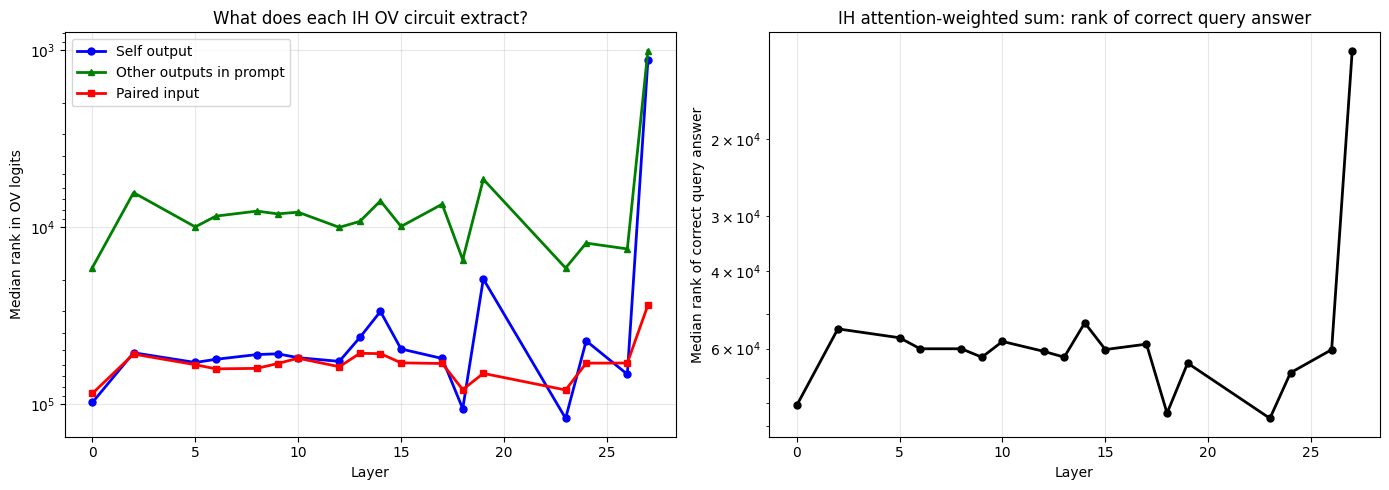


Layer      Self     Other     Input    SumQuery
----------------------------------------------
    0     98327     16995     87406       80816
    2     51498      6412     52404       54102
    5     58436     10014     60153       56684
    6     56077      8705     63500       60051
    8     52714      8156     63095       60049
    9     52213      8452     59257       62762
   10     54900      8272     55284       57790
   12     57603     10074     61755       60856
   13     42204      9322     51893       62762
   14     30084      7136     52068       52420
   15     49008      9960     58724       60296
   17     55477      7452     59217       58609
   18    106633     15344     83122       84167
   19     19717      5389     67340       64748
   23    120878     17098     83592       86488
   24     44108     12364     58951       68109
   26     68138     13337     58866       60334
   27      1141      1012     27713       12582


In [9]:
layers_with_ihs = sorted(set(l for l, h in output_attending_heads))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(layers_with_ihs, [np.median(ov_self_rank[l]) for l in layers_with_ihs],
            'b-o', ms=5, lw=2, label='Self output')
ax.semilogy(layers_with_ihs, [np.median(ov_other_rank[l]) for l in layers_with_ihs],
            'g-^', ms=5, lw=2, label='Other outputs in prompt')
ax.semilogy(layers_with_ihs, [np.median(ov_input_rank[l]) for l in layers_with_ihs],
            'r-s', ms=5, lw=2, label='Paired input')
ax.set_xlabel('Layer'); ax.set_ylabel('Median rank in OV logits')
ax.set_title('What does each IH OV circuit extract?')
ax.legend(); ax.grid(True, alpha=0.3); ax.invert_yaxis()

ax = axes[1]
ax.semilogy(layers_with_ihs, [np.median(sum_query_rank[l]) for l in layers_with_ihs],
            'k-o', ms=5, lw=2)
ax.set_xlabel('Layer'); ax.set_ylabel('Median rank of correct query answer')
ax.set_title('IH attention-weighted sum: rank of correct query answer')
ax.grid(True, alpha=0.3); ax.invert_yaxis()

plt.tight_layout()
plt.show()

print(f'\n{"Layer":>5}  {"Self":>8}  {"Other":>8}  {"Input":>8}  {"SumQuery":>10}')
print('-' * 46)
for l in layers_with_ihs:
    print(f'{l:5d}  {np.median(ov_self_rank[l]):8.0f}  '
          f'{np.median(ov_other_rank[l]):8.0f}  '
          f'{np.median(ov_input_rank[l]):8.0f}  '
          f'{np.median(sum_query_rank[l]):10.0f}')

In [10]:
# Save
results = {
    'ov_self_rank': dict(ov_self_rank),
    'ov_other_rank': dict(ov_other_rank),
    'ov_input_rank': dict(ov_input_rank),
    'sum_query_rank': dict(sum_query_rank),
}
with open('ov_logit_lens_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print('Saved ov_logit_lens_results.pkl')

Saved ov_logit_lens_results.pkl


## New

In [5]:
import time
 
N_PROMPTS = 5
NAMES_FILTER_RANK = lambda name: ('hook_attn_out' in name or
                                   'hook_mlp_out' in name or
                                   'resid_pre' in name)
 
# layer -> list of ranks at the final position
rank_pre = defaultdict(list)        # resid_pre[l]
rank_post_attn = defaultdict(list)  # resid_pre[l] + attn_out[l]
rank_post_mlp = defaultdict(list)   # resid_pre[l] + attn_out[l] + mlp_out[l]
 
# Also track: rank of QUERY INPUT word (should start low, get suppressed)
rank_pre_query = defaultdict(list)
rank_post_attn_query = defaultdict(list)
rank_post_mlp_query = defaultdict(list)
 
device = model.cfg.device
W_U_gpu = model.W_U  # [d_model, vocab]
 
t0 = time.time()
total = len(all_splits) * N_PROMPTS
pbar = tqdm(total=total, desc='answer rank')
 
for task_name, splits in all_splits.items():
    eval_data = splits['eval_data']
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS]):
        prompt = pdata['prompt']
        tokens = model.to_tokens(prompt, prepend_bos=True)
        last_pos = tokens.shape[1] - 1

        # Get the correct answer for THIS prompt's query
        # (not eq, which is an unrelated eval pair)
        query_input = pdata['query_input']
        if 'query_output' in pdata:
            correct_answer = pdata['query_output']
        else:
            # Fall back to looking up in the task's pair list
            task_pairs_dict = dict(tasks[task_name])
            correct_answer = task_pairs_dict.get(query_input)
            if correct_answer is None:
                pbar.update(1)
                continue

        # Token IDs we care about (with leading space — model produces ' Tokyo' not 'Tokyo')
        answer_tok = first_tok_id(' ' + correct_answer, model)
        query_tok = first_tok_id(' ' + query_input, model)
 
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=NAMES_FILTER_RANK)
 
            for l in range(n_layers):
                pre = cache[f'blocks.{l}.hook_resid_pre'][0, last_pos]
                attn = cache[f'blocks.{l}.hook_attn_out'][0, last_pos]
                mlp = cache[f'blocks.{l}.hook_mlp_out'][0, last_pos]
 
                vecs = torch.stack([pre, pre + attn, pre + attn + mlp], dim=0)  # [3, d_model]
                normed = model.ln_final(vecs)
                logits = normed @ W_U_gpu  # [3, vocab]
 
                # rank = number of tokens with strictly higher logit
                ans_logits = logits[:, answer_tok]
                qry_logits = logits[:, query_tok]
 
                rank_pre[l].append((logits[0] > ans_logits[0]).sum().item())
                rank_post_attn[l].append((logits[1] > ans_logits[1]).sum().item())
                rank_post_mlp[l].append((logits[2] > ans_logits[2]).sum().item())
 
                rank_pre_query[l].append((logits[0] > qry_logits[0]).sum().item())
                rank_post_attn_query[l].append((logits[1] > qry_logits[1]).sum().item())
                rank_post_mlp_query[l].append((logits[2] > qry_logits[2]).sum().item())
 
        del cache
        torch.cuda.empty_cache()
        pbar.update(1)
 
pbar.close()
print(f'Done in {time.time()-t0:.0f}s')

answer rank: 100%|██████████| 100/100 [00:09<00:00, 10.83it/s]

Done in 9s


In [6]:
import time

# Group output-attending heads by layer for easier hooking
ih_by_layer = defaultdict(list)
for l, h in output_attending_heads:
    ih_by_layer[l].append(h)

N_PROMPTS = 5
NAMES_FILTER_RANK = lambda name: ('hook_attn_out' in name or
                                   'hook_mlp_out' in name or
                                   'resid_pre' in name)

abl_rank_pre = defaultdict(list)
abl_rank_post_attn = defaultdict(list)
abl_rank_post_mlp = defaultdict(list)

W_U_gpu = model.W_U
device = model.cfg.device

def make_ablation_hook(heads_to_zero, last_pos):
    """Zero the specified heads' z output at the final position."""
    def hook_fn(z, hook):
        # z shape: [batch, seq, n_heads, d_head]
        for h in heads_to_zero:
            z[:, last_pos, h, :] = 0
        return z
    return hook_fn

t0 = time.time()
total = len(all_splits) * N_PROMPTS
pbar = tqdm(total=total, desc='ablated rank')

for task_name, splits in all_splits.items():
    task_pairs_dict = dict(tasks[task_name])
    
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS]):
        prompt = pdata['prompt']
        tokens = model.to_tokens(prompt, prepend_bos=True)
        last_pos = tokens.shape[1] - 1
        
        query_input = pdata['query_input']
        if 'query_output' in pdata:
            correct_answer = pdata['query_output']
        else:
            correct_answer = task_pairs_dict.get(query_input)
            if correct_answer is None:
                pbar.update(1)
                continue
        
        answer_tok = first_tok_id(' ' + correct_answer, model)
        
        # Build ablation hooks for all layers with output-attending IHs
        hooks = []
        for layer, heads in ih_by_layer.items():
            hook_name = f'blocks.{layer}.attn.hook_z'
            hooks.append((hook_name, make_ablation_hook(heads, last_pos)))
        
        with torch.no_grad(), model.hooks(fwd_hooks=hooks):
            _, cache = model.run_with_cache(
                tokens,
                names_filter=NAMES_FILTER_RANK,
            )
            
            for l in range(n_layers):
                pre = cache[f'blocks.{l}.hook_resid_pre'][0, last_pos]
                attn = cache[f'blocks.{l}.hook_attn_out'][0, last_pos]
                mlp = cache[f'blocks.{l}.hook_mlp_out'][0, last_pos]
                
                vecs = torch.stack([pre, pre + attn, pre + attn + mlp], dim=0)
                normed = model.ln_final(vecs)
                logits = normed @ W_U_gpu
                
                ans_logits = logits[:, answer_tok]
                abl_rank_pre[l].append((logits[0] > ans_logits[0]).sum().item())
                abl_rank_post_attn[l].append((logits[1] > ans_logits[1]).sum().item())
                abl_rank_post_mlp[l].append((logits[2] > ans_logits[2]).sum().item())
        
        del cache
        torch.cuda.empty_cache()
        pbar.update(1)

pbar.close()
print(f'Done in {time.time()-t0:.0f}s')

ablated rank: 100%|██████████| 100/100 [00:09<00:00, 10.81it/s]

Done in 9s


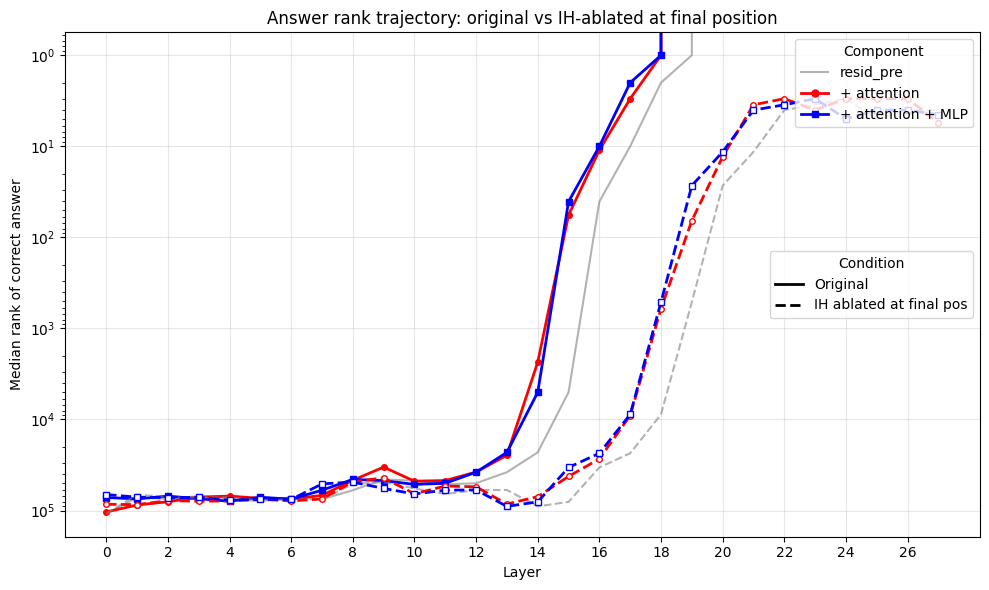

In [7]:
layers = list(range(n_layers))

fig, ax = plt.subplots(figsize=(10, 6))

# Three colors for the three component types
colors = {'pre': 'gray', 'attn': 'red', 'mlp': 'blue'}

# Original: solid lines, filled markers
ax.semilogy(layers, [np.median(rank_pre[l]) for l in layers],
            color=colors['pre'], ls='-', lw=1.5, alpha=0.6)
ax.semilogy(layers, [np.median(rank_post_attn[l]) for l in layers],
            color=colors['attn'], ls='-', marker='o', ms=4, lw=2)
ax.semilogy(layers, [np.median(rank_post_mlp[l]) for l in layers],
            color=colors['mlp'], ls='-', marker='s', ms=4, lw=2)

# Ablated: dashed lines, open markers
ax.semilogy(layers, [np.median(abl_rank_pre[l]) for l in layers],
            color=colors['pre'], ls='--', lw=1.5, alpha=0.6)
ax.semilogy(layers, [np.median(abl_rank_post_attn[l]) for l in layers],
            color=colors['attn'], ls='--', marker='o', ms=4, lw=2, mfc='white')
ax.semilogy(layers, [np.median(abl_rank_post_mlp[l]) for l in layers],
            color=colors['mlp'], ls='--', marker='s', ms=4, lw=2, mfc='white')

ax.set_xlabel('Layer')
ax.set_ylabel('Median rank of correct answer')
ax.set_title('Answer rank trajectory: original vs IH-ablated at final position')
ax.grid(True, alpha=0.3)
ax.invert_yaxis()
ax.set_xticks(range(0, n_layers, 2))

# Two-part legend: components (color) and condition (line style)
from matplotlib.lines import Line2D
component_handles = [
    Line2D([0], [0], color=colors['pre'], lw=1.5, alpha=0.6, label='resid_pre'),
    Line2D([0], [0], color=colors['attn'], lw=2, marker='o', ms=5, label='+ attention'),
    Line2D([0], [0], color=colors['mlp'], lw=2, marker='s', ms=5, label='+ attention + MLP'),
]
condition_handles = [
    Line2D([0], [0], color='black', lw=2, ls='-', label='Original'),
    Line2D([0], [0], color='black', lw=2, ls='--', label='IH ablated at final pos'),
]

leg1 = ax.legend(handles=component_handles, loc='upper right', title='Component')
ax.add_artist(leg1)
ax.legend(handles=condition_handles, loc='center right', title='Condition')

plt.tight_layout()
plt.show()

In [8]:
import time

abl_all_rank_pre = defaultdict(list)
abl_all_rank_post_attn = defaultdict(list)
abl_all_rank_post_mlp = defaultdict(list)

def make_ablation_hook_all_positions(heads_to_zero):
    """Zero the specified heads' z output at ALL positions."""
    def hook_fn(z, hook):
        # z shape: [batch, seq, n_heads, d_head]
        for h in heads_to_zero:
            z[:, :, h, :] = 0
        return z
    return hook_fn

t0 = time.time()
total = len(all_splits) * N_PROMPTS
pbar = tqdm(total=total, desc='ablated all-pos rank')

for task_name, splits in all_splits.items():
    task_pairs_dict = dict(tasks[task_name])
    
    for p_idx, pdata in enumerate(splits['icl_prompts'][:N_PROMPTS]):
        prompt = pdata['prompt']
        tokens = model.to_tokens(prompt, prepend_bos=True)
        last_pos = tokens.shape[1] - 1
        
        query_input = pdata['query_input']
        if 'query_output' in pdata:
            correct_answer = pdata['query_output']
        else:
            correct_answer = task_pairs_dict.get(query_input)
            if correct_answer is None:
                pbar.update(1)
                continue
        
        answer_tok = first_tok_id(' ' + correct_answer, model)
        
        # Ablation hooks at ALL positions
        hooks = []
        for layer, heads in ih_by_layer.items():
            hook_name = f'blocks.{layer}.attn.hook_z'
            hooks.append((hook_name, make_ablation_hook_all_positions(heads)))
        
        with torch.no_grad(), model.hooks(fwd_hooks=hooks):
            _, cache = model.run_with_cache(
                tokens,
                names_filter=NAMES_FILTER_RANK,
            )
            
            for l in range(n_layers):
                pre = cache[f'blocks.{l}.hook_resid_pre'][0, last_pos]
                attn = cache[f'blocks.{l}.hook_attn_out'][0, last_pos]
                mlp = cache[f'blocks.{l}.hook_mlp_out'][0, last_pos]
                
                vecs = torch.stack([pre, pre + attn, pre + attn + mlp], dim=0)
                normed = model.ln_final(vecs)
                logits = normed @ W_U_gpu
                
                ans_logits = logits[:, answer_tok]
                abl_all_rank_pre[l].append((logits[0] > ans_logits[0]).sum().item())
                abl_all_rank_post_attn[l].append((logits[1] > ans_logits[1]).sum().item())
                abl_all_rank_post_mlp[l].append((logits[2] > ans_logits[2]).sum().item())
        
        del cache
        torch.cuda.empty_cache()
        pbar.update(1)

pbar.close()
print(f'Done in {time.time()-t0:.0f}s')

ablated all-pos rank: 100%|██████████| 100/100 [00:09<00:00, 11.05it/s]

Done in 9s


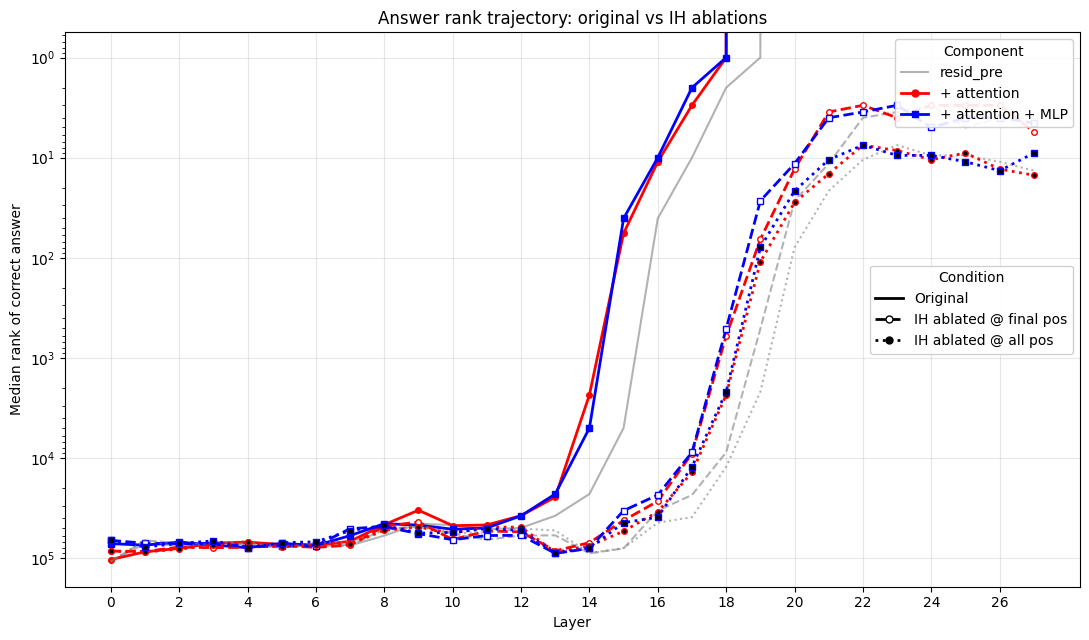


Layer      Orig    AblFinal     AblAll
------------------------------------
    0     71964       66714      66714
    1     74464       71314      77596
    2     69439       71948      71602
    3     74220       71633      67448
    4     79005       76991      78921
    5     71418       75509      70326
    6     75062       75622      68964
    7     59821       50950      53370
    8     45464       48665      47215
    9     46948       57160      56516
   10     51660       65751      55512
   11     50114       59682      50913
   12     37905       59429      53116
   13     22973       89971      89264
   14      5031       80318      79643
   15        40       33656      44432
   16        10       23484      39098
   17         2        8799      12292
   18         1         514       2188
   19         0          27         79
   20         0          12         22
   21         0           4         10
   22         0           4          8
   23         0           

In [10]:
layers = list(range(n_layers))

fig, ax = plt.subplots(figsize=(11, 6.5))

colors = {'pre': 'gray', 'attn': 'red', 'mlp': 'blue'}

conditions = [
    ('Original', '-',  None,    rank_pre,         rank_post_attn,         rank_post_mlp),
    ('IH abl @ final', '--', 'white', abl_rank_pre,     abl_rank_post_attn,     abl_rank_post_mlp),
    ('IH abl @ all',   ':',  'black', abl_all_rank_pre, abl_all_rank_post_attn, abl_all_rank_post_mlp),
]

for label, ls, mfc, pre_d, attn_d, mlp_d in conditions:
    mfc_kw = {'mfc': mfc} if mfc is not None else {}
    ax.semilogy(layers, [np.median(pre_d[l])  for l in layers],
                color=colors['pre'],  ls=ls, lw=1.5, alpha=0.6)
    ax.semilogy(layers, [np.median(attn_d[l]) for l in layers],
                color=colors['attn'], ls=ls, marker='o', ms=4, lw=2, **mfc_kw)
    ax.semilogy(layers, [np.median(mlp_d[l])  for l in layers],
                color=colors['mlp'],  ls=ls, marker='s', ms=4, lw=2, **mfc_kw)

ax.set_xlabel('Layer')
ax.set_ylabel('Median rank of correct answer')
ax.set_title('Answer rank trajectory: original vs IH ablations')
ax.grid(True, alpha=0.3); ax.invert_yaxis()
ax.set_xticks(range(0, n_layers, 2))

from matplotlib.lines import Line2D
component_handles = [
    Line2D([0], [0], color=colors['pre'],  lw=1.5, alpha=0.6, label='resid_pre'),
    Line2D([0], [0], color=colors['attn'], lw=2, marker='o', ms=5, label='+ attention'),
    Line2D([0], [0], color=colors['mlp'],  lw=2, marker='s', ms=5, label='+ attention + MLP'),
]
condition_handles = [
    Line2D([0], [0], color='black', lw=2, ls='-',  label='Original'),
    Line2D([0], [0], color='black', lw=2, ls='--', marker='o', ms=5, mfc='white', label='IH ablated @ final pos'),
    Line2D([0], [0], color='black', lw=2, ls=':',  marker='o', ms=5, mfc='black', label='IH ablated @ all pos'),
]

leg1 = ax.legend(handles=component_handles, loc='upper right', title='Component', framealpha=0.9)
ax.add_artist(leg1)
ax.legend(handles=condition_handles, loc='center right', title='Condition', framealpha=0.9)

plt.tight_layout()
plt.show()

# Punchline table
print(f'\n{"Layer":>5}  {"Orig":>8}  {"AblFinal":>10}  {"AblAll":>9}')
print('-' * 36)
for l in range(n_layers):
    o = np.median(rank_post_mlp[l])
    af = np.median(abl_rank_post_mlp[l])
    aa = np.median(abl_all_rank_post_mlp[l])
    print(f'{l:5d}  {o:8.0f}  {af:10.0f}  {aa:9.0f}')

In [26]:
import time
from collections import defaultdict
from contextlib import nullcontext

# --- Setup: re-collect IHs if needed ---
try:
    output_attending_heads
except NameError:
    all_prompts_sub = []
    for task_name, splits in all_splits.items():
        for pdata in splits['icl_prompts'][:5]:
            all_prompts_sub.append(pdata)
    _, attn_to_out, _ = extract_attention_patterns(model, all_prompts_sub)
    output_attending_heads = select_top_heads(attn_to_out, percentile=90)
    print(f'Output-attending heads: {len(output_attending_heads)}')

ih_by_layer = defaultdict(list)
for l, h in output_attending_heads:
    ih_by_layer[l].append(h)

# --- Helper: get token id with leading space ---
def first_tok_id(word, model):
    return model.to_tokens(' ' + word, prepend_bos=False)[0][0].item()

W_U_gpu = model.W_U  # [d_model, vocab]

NAMES_FILTER = lambda name: ('hook_attn_out' in name or
                              'hook_mlp_out' in name or
                              'resid_pre' in name)

def make_ablation_hook(heads_to_zero, last_pos):
    def hook_fn(z, hook):
        for h in heads_to_zero:
            z[:, last_pos, h, :] = 0
        return z
    return hook_fn

# --- Collect orig and ablated trajectories + answer direction per prompt ---
N_PROMPTS = 5
orig_trajectories = []
abl_trajectories = []
answer_directions = []

t0 = time.time()
total = len(all_splits) * N_PROMPTS
pbar = tqdm(total=total, desc='collecting')

for task_name, splits in all_splits.items():
    task_pairs_dict = dict(tasks[task_name])
    
    for pdata in splits['icl_prompts'][:N_PROMPTS]:
        prompt = pdata['prompt']
        tokens = model.to_tokens(prompt, prepend_bos=True)
        last_pos = tokens.shape[1] - 1
        
        # Get correct answer for this prompt
        query_input = pdata['query_input']
        if 'query_output' in pdata:
            correct_answer = pdata['query_output']
        else:
            correct_answer = task_pairs_dict.get(query_input)
            if correct_answer is None:
                pbar.update(1)
                continue
        
        ans_tok = first_tok_id(correct_answer, model)
        
        ans_dir = model.W_U[:, ans_tok].detach().cpu().float().numpy()
        ans_dir = ans_dir / (np.linalg.norm(ans_dir) + 1e-10)
        
        # Build ablation hooks for IH outputs at final position
        hooks = []
        for layer, heads in ih_by_layer.items():
            hook_name = f'blocks.{layer}.attn.hook_z'
            hooks.append((hook_name, make_ablation_hook(heads, last_pos)))
        
        # Original trajectory
        with torch.no_grad():
            _, cache_orig = model.run_with_cache(tokens, names_filter=NAMES_FILTER)
        
        traj_orig = torch.zeros(n_layers, 3, d_model, dtype=torch.float32)
        for l in range(n_layers):
            pre = cache_orig[f'blocks.{l}.hook_resid_pre'][0, last_pos].cpu().float()
            attn = cache_orig[f'blocks.{l}.hook_attn_out'][0, last_pos].cpu().float()
            mlp = cache_orig[f'blocks.{l}.hook_mlp_out'][0, last_pos].cpu().float()
            traj_orig[l, 0] = pre
            traj_orig[l, 1] = pre + attn
            traj_orig[l, 2] = pre + attn + mlp
        del cache_orig
        torch.cuda.empty_cache()
        
        # Ablated trajectory
        with torch.no_grad(), model.hooks(fwd_hooks=hooks):
            _, cache_abl = model.run_with_cache(tokens, names_filter=NAMES_FILTER)
        
        traj_abl = torch.zeros(n_layers, 3, d_model, dtype=torch.float32)
        for l in range(n_layers):
            pre = cache_abl[f'blocks.{l}.hook_resid_pre'][0, last_pos].cpu().float()
            attn = cache_abl[f'blocks.{l}.hook_attn_out'][0, last_pos].cpu().float()
            mlp = cache_abl[f'blocks.{l}.hook_mlp_out'][0, last_pos].cpu().float()
            traj_abl[l, 0] = pre
            traj_abl[l, 1] = pre + attn
            traj_abl[l, 2] = pre + attn + mlp
        del cache_abl
        torch.cuda.empty_cache()
        
        orig_trajectories.append(traj_orig)
        abl_trajectories.append(traj_abl)
        answer_directions.append(ans_dir)
        pbar.update(1)

pbar.close()
print(f'Done in {time.time()-t0:.0f}s, collected {len(orig_trajectories)} prompts')

collecting: 100%|██████████| 100/100 [00:10<00:00,  9.27it/s]

Done in 11s, collected 100 prompts


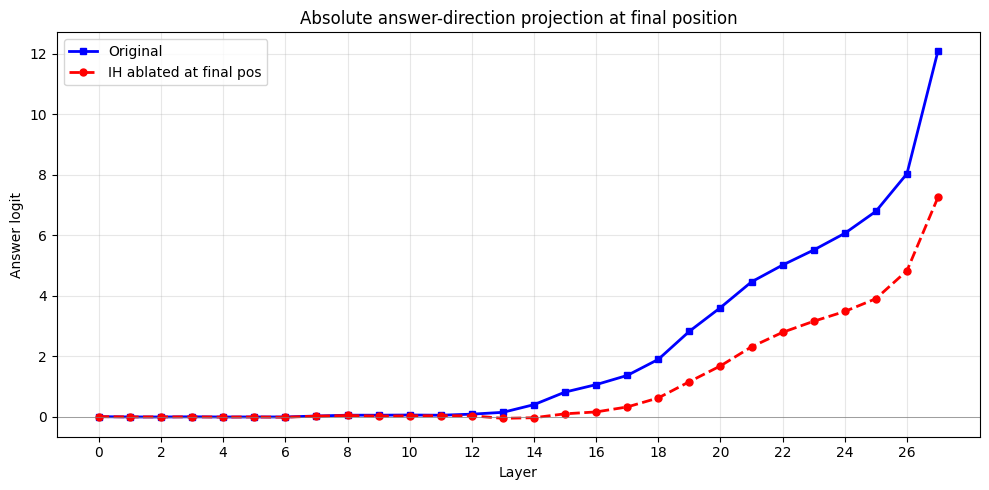


Layer      Orig    Ablated      Diff
------------------------------------
    0    -0.004     -0.002    -0.001
    4    -0.015     -0.017    +0.002
    8     0.045      0.035    +0.010
   12     0.079      0.024    +0.055
   14     0.394     -0.040    +0.433
   16     1.056      0.153    +0.903
   20     3.606      1.676    +1.930
   24     6.065      3.478    +2.587
   27    12.108      7.261    +4.847


In [27]:
# --- Compute projections and plot ---
import numpy as np

orig_stack = torch.stack(orig_trajectories).numpy()  # [N, n_layers, 3, d_model]
abl_stack = torch.stack(abl_trajectories).numpy()

# Projections
orig_proj = np.zeros((len(orig_trajectories), n_layers, 3))
abl_proj = np.zeros((len(orig_trajectories), n_layers, 3))
for i, ans_dir in enumerate(answer_directions):
    orig_proj[i] = orig_stack[i] @ ans_dir
    abl_proj[i] = abl_stack[i] @ ans_dir

mean_orig = orig_proj.mean(axis=0)  # [n_layers, 3]
mean_abl = abl_proj.mean(axis=0)

# Plot post-MLP curves (final state of each layer)
fig, ax = plt.subplots(figsize=(10, 5))
layers = list(range(n_layers))
ax.plot(layers, mean_orig[:, 2], 'b-s', ms=5, lw=2, label='Original')
ax.plot(layers, mean_abl[:, 2], 'r--o', ms=5, lw=2, label='IH ablated at final pos')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('Layer')
ax.set_ylabel('Answer logit')
ax.set_title('Absolute answer-direction projection at final position')
ax.set_xticks(range(0, n_layers, 2))
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Print key layers
print(f'\n{"Layer":>5}  {"Orig":>8}  {"Ablated":>9}  {"Diff":>8}')
print('-' * 36)
for l in [0, 4, 8, 12, 14, 16, 20, 24, 27]:
    o = mean_orig[l, 2]
    a = mean_abl[l, 2]
    print(f'{l:>5}  {o:>8.3f}  {a:>9.3f}  {o-a:>+8.3f}')

## Do output positions have task information

collecting: 100%|██████████| 20/20 [00:07<00:00,  2.71it/s]


Collected 100 IH writes

Same-task pairs:  mean sim 0.7769 (n=200)
Cross-task pairs: mean sim 0.3302 (n=4750)
Ratio: 2.35x


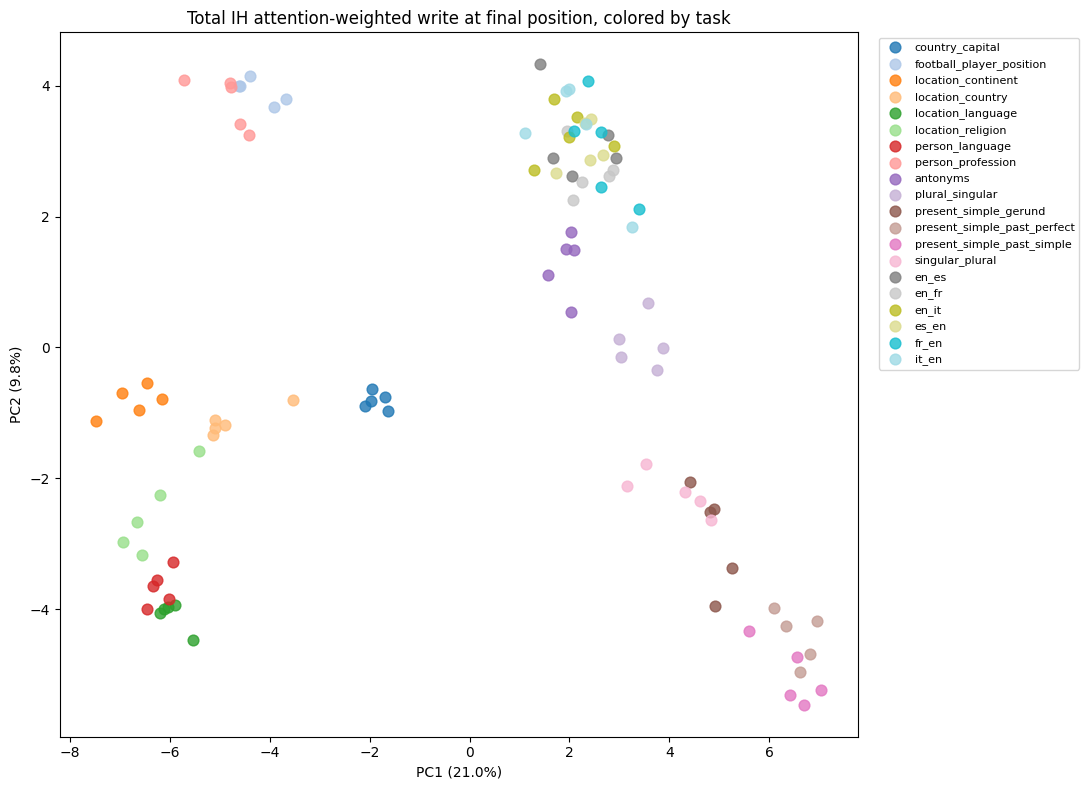

In [5]:
import time

LAYER_LIST = sorted(set(l for l, h in output_attending_heads))
NAMES = lambda name: any(f'blocks.{L}.attn.hook_pattern' in name or 
                          f'blocks.{L}.attn.hook_v' in name 
                          for L in LAYER_LIST)

# For each prompt: compute IH's attention-weighted OV contribution at final pos
# Sum across all output-attending heads to get one "total IH write" per prompt
total_ih_writes = []   # [n_prompts, d_model]
prompt_tasks = []

for task_name, splits in tqdm(all_splits.items(), desc='collecting'):
    for pdata in splits['icl_prompts'][:5]:
        prompt = pdata['prompt']
        tokens = model.to_tokens(prompt, prepend_bos=True)
        last_pos = tokens.shape[1] - 1
        
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=NAMES)
        
        total_write = np.zeros(d_model)
        for l, h in output_attending_heads:
            # Attention pattern from final pos: [seq]
            attn = cache[f'blocks.{l}.attn.hook_pattern'][0, h, last_pos].cpu().float().numpy()
            # V values across all positions: [seq, d_head]
            n_kv = cache[f'blocks.{l}.attn.hook_v'].shape[2]
            kv_h = h * n_kv // model.cfg.n_heads  # map query head -> kv head
            v = cache[f'blocks.{l}.attn.hook_v'][0, :, kv_h].cpu().float().numpy()
            # Attention-weighted sum of V: [d_head]
            z = (attn[:, None] * v).sum(axis=0)
            # Project through W_O to get residual stream contribution
            W_O = model.blocks[l].attn.W_O[h].detach().cpu().float().numpy()
            total_write += z @ W_O
        
        total_ih_writes.append(total_write)
        prompt_tasks.append(task_name)
        
        del cache
        torch.cuda.empty_cache()

total_ih_writes = np.array(total_ih_writes)
prompt_tasks = np.array(prompt_tasks)
print(f'Collected {len(total_ih_writes)} IH writes')

# Test: do same-task prompts have more similar IH writes than cross-task pairs?
unique_tasks = sorted(set(prompt_tasks))
n = len(total_ih_writes)

# Compute all pairwise cosine similarities
norms = np.linalg.norm(total_ih_writes, axis=1, keepdims=True)
normalized = total_ih_writes / (norms + 1e-12)
sims = normalized @ normalized.T  # [n, n]

# Same-task vs cross-task
same_task_sims = []
cross_task_sims = []
for i in range(n):
    for j in range(i+1, n):
        if prompt_tasks[i] == prompt_tasks[j]:
            same_task_sims.append(sims[i, j])
        else:
            cross_task_sims.append(sims[i, j])

same_task_sims = np.array(same_task_sims)
cross_task_sims = np.array(cross_task_sims)

print(f'\nSame-task pairs:  mean sim {same_task_sims.mean():.4f} (n={len(same_task_sims)})')
print(f'Cross-task pairs: mean sim {cross_task_sims.mean():.4f} (n={len(cross_task_sims)})')
print(f'Ratio: {same_task_sims.mean() / (cross_task_sims.mean() + 1e-12):.2f}x')

# PCA visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
proj = pca.fit_transform(total_ih_writes)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_tasks)))
task_to_color = dict(zip(unique_tasks, colors))

fig, ax = plt.subplots(figsize=(11, 8))
for task in unique_tasks:
    mask = prompt_tasks == task
    ax.scatter(proj[mask, 0], proj[mask, 1], c=[task_to_color[task]], 
               label=task.split('/')[-1], s=60, alpha=0.8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Total IH attention-weighted write at final position, colored by task')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

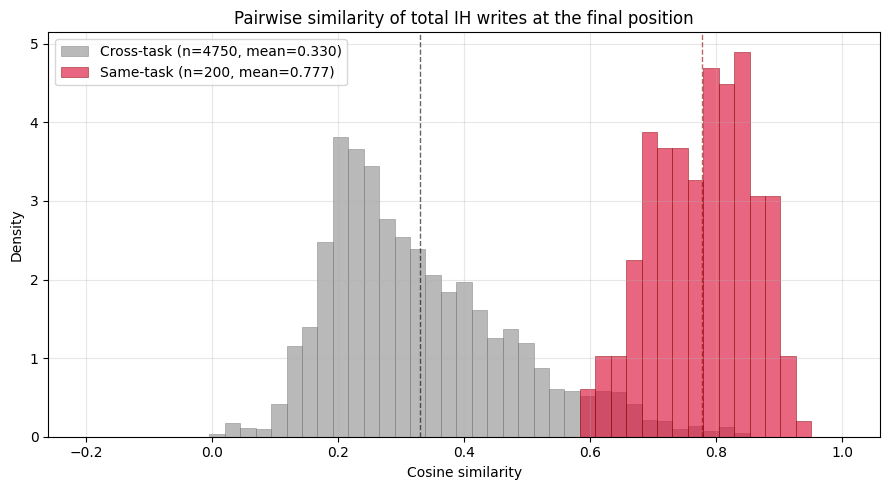

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

bins = np.linspace(-0.2, 1.0, 50)
ax.hist(cross_task_sims, bins=bins, alpha=0.55, color='gray', 
        label=f'Cross-task (n={len(cross_task_sims)}, mean={cross_task_sims.mean():.3f})',
        density=True, edgecolor='dimgray', linewidth=0.5)
ax.hist(same_task_sims, bins=bins, alpha=0.65, color='crimson',
        label=f'Same-task (n={len(same_task_sims)}, mean={same_task_sims.mean():.3f})',
        density=True, edgecolor='darkred', linewidth=0.5)

ax.axvline(cross_task_sims.mean(), color='black', ls='--', lw=1, alpha=0.6)
ax.axvline(same_task_sims.mean(), color='darkred', ls='--', lw=1, alpha=0.6)

ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Density')
ax.set_title('Pairwise similarity of total IH writes at the final position')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
import time
from collections import defaultdict

NAMES = lambda name: ('hook_pattern' in name or 'hook_v' in name)

# Per-head writes: {(l, h): list of d_model vectors, one per prompt}
per_head_writes = defaultdict(list)
prompt_tasks = []

for task_name, splits in tqdm(all_splits.items(), desc='collecting'):
    for pdata in splits['icl_prompts'][:5]:
        prompt = pdata['prompt']
        tokens = model.to_tokens(prompt, prepend_bos=True)
        last_pos = tokens.shape[1] - 1
        
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=NAMES)
        
        for l, h in output_attending_heads:
            attn = cache[f'blocks.{l}.attn.hook_pattern'][0, h, last_pos].cpu().float().numpy()
            n_kv = cache[f'blocks.{l}.attn.hook_v'].shape[2]
            kv_h = h * n_kv // model.cfg.n_heads
            v = cache[f'blocks.{l}.attn.hook_v'][0, :, kv_h].cpu().float().numpy()
            z = (attn[:, None] * v).sum(axis=0)  # [d_head]
            W_O = model.blocks[l].attn.W_O[h].detach().cpu().float().numpy()
            write = z @ W_O  # [d_model]
            per_head_writes[(l, h)].append(write)
        
        prompt_tasks.append(task_name)
        del cache
        torch.cuda.empty_cache()

prompt_tasks = np.array(prompt_tasks)
print(f'Collected writes for {len(output_attending_heads)} heads × {len(prompt_tasks)} prompts')

collecting: 100%|██████████| 20/20 [00:07<00:00,  2.78it/s]

Collected writes for 68 heads × 100 prompts


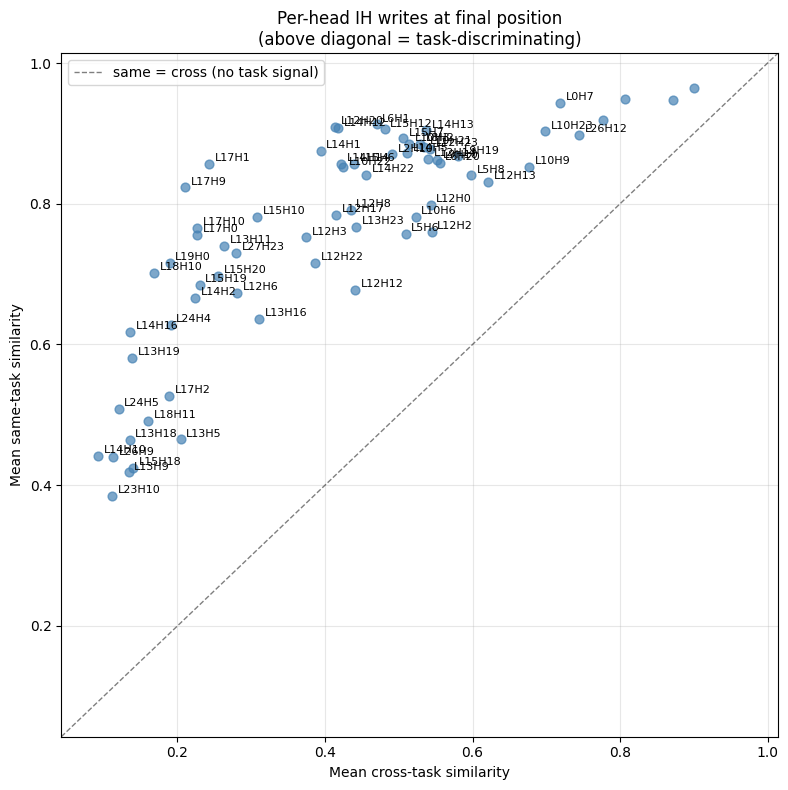

In [8]:
# Per-head: compute same-task vs cross-task cosines
n = len(prompt_tasks)
head_stats = {}  # (l, h) -> dict with same/cross arrays + means

for (l, h), writes in per_head_writes.items():
    W = np.array(writes)
    norms = np.linalg.norm(W, axis=1, keepdims=True)
    Wn = W / (norms + 1e-12)
    sims = Wn @ Wn.T
    
    same, cross = [], []
    for i in range(n):
        for j in range(i+1, n):
            (same if prompt_tasks[i] == prompt_tasks[j] else cross).append(sims[i, j])
    
    head_stats[(l, h)] = {
        'same': np.array(same),
        'cross': np.array(cross),
        'same_mean': np.mean(same),
        'cross_mean': np.mean(cross),
        'diff': np.mean(same) - np.mean(cross),
    }

# Sort heads by diff (most task-discriminating first)
sorted_heads = sorted(head_stats.items(), key=lambda x: -x[1]['diff'])

# Summary scatter: every head as a point, x = cross-task mean, y = same-task mean
fig, ax = plt.subplots(figsize=(8, 8))
for (l, h), s in head_stats.items():
    ax.scatter(s['cross_mean'], s['same_mean'], c='steelblue', s=40, alpha=0.7)
    if s['diff'] > 0.15:  # label strong heads
        ax.annotate(f'L{l}H{h}', (s['cross_mean'], s['same_mean']),
                    xytext=(4, 2), textcoords='offset points', fontsize=8)

# Diagonal: same == cross (no task discrimination)
lo = min(min(s['cross_mean'] for s in head_stats.values()),
         min(s['same_mean'] for s in head_stats.values())) - 0.05
hi = max(max(s['cross_mean'] for s in head_stats.values()),
         max(s['same_mean'] for s in head_stats.values())) + 0.05
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.5, label='same = cross (no task signal)')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel('Mean cross-task similarity')
ax.set_ylabel('Mean same-task similarity')
ax.set_title('Per-head IH writes at final position\n(above diagonal = task-discriminating)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

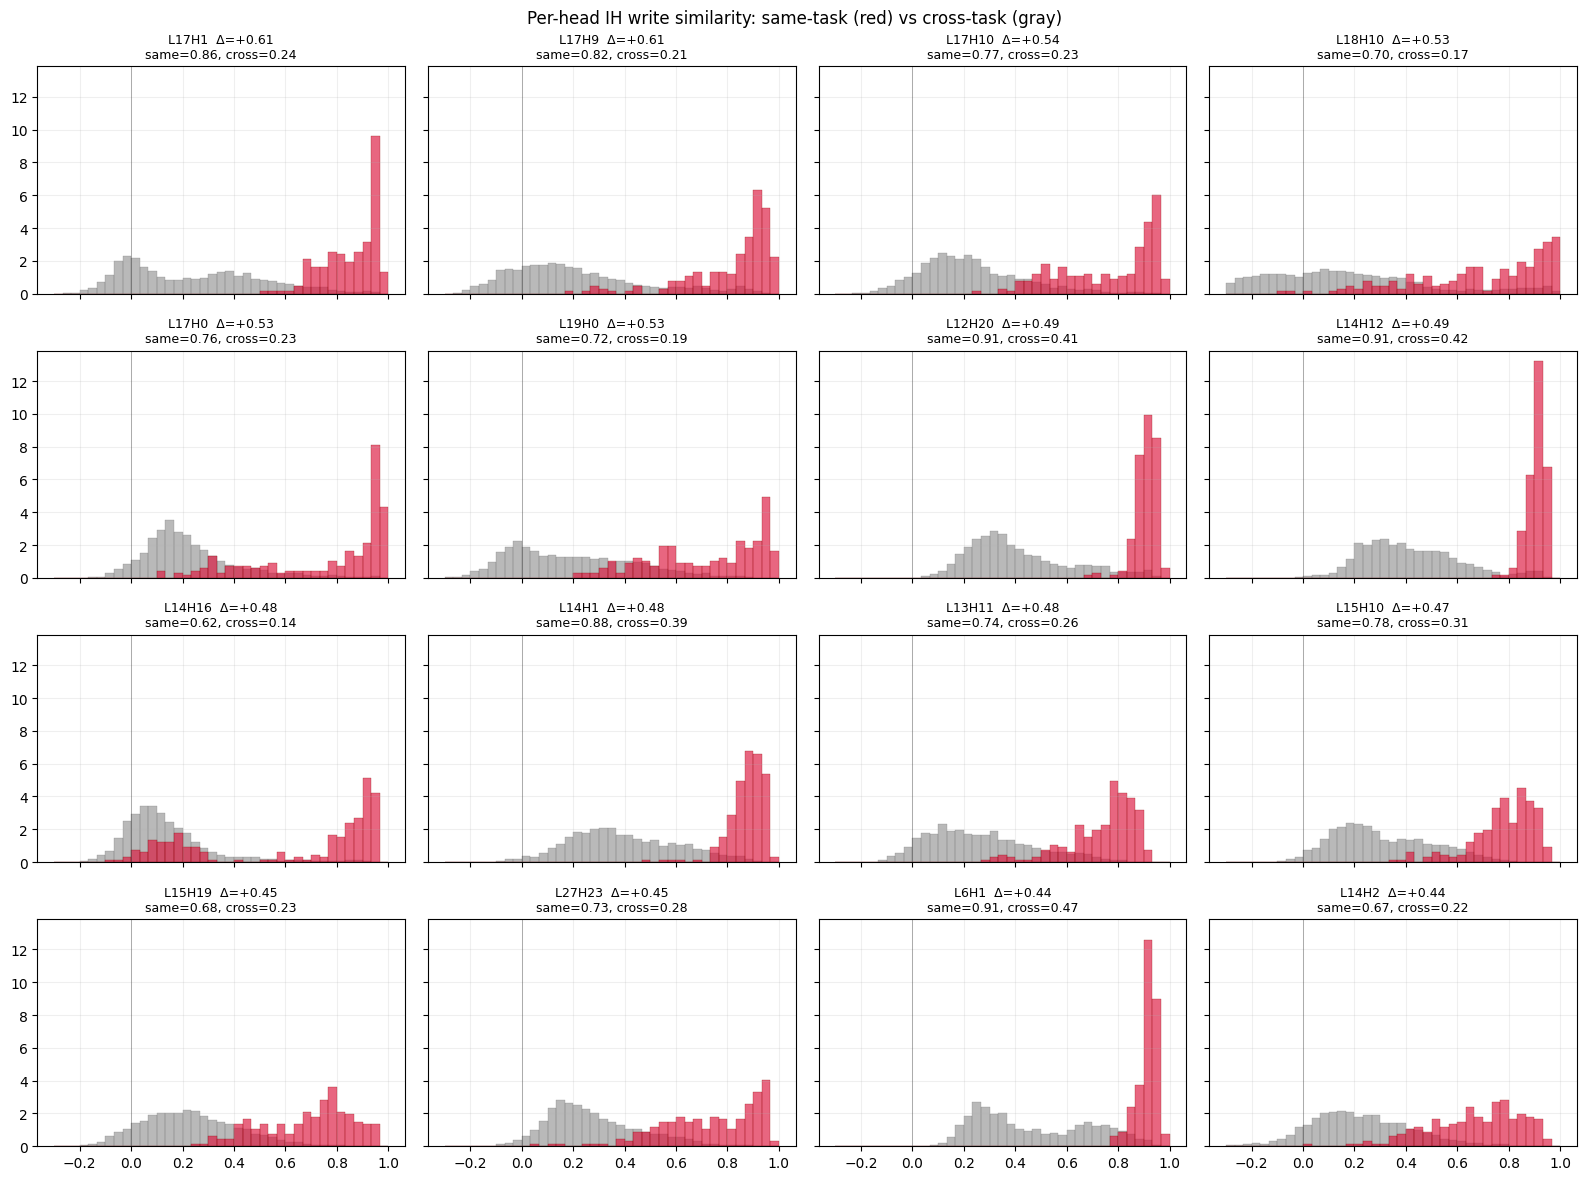


Head          Same   Cross    Diff
---------------------------------
L17H1        0.857   0.243  +0.614
L17H9        0.823   0.210  +0.613
L17H10       0.766   0.226  +0.539
L18H10       0.701   0.168  +0.533
L17H0        0.756   0.227  +0.529
L19H0        0.716   0.190  +0.526
L12H20       0.909   0.414  +0.495
L14H12       0.907   0.418  +0.489
L14H16       0.618   0.136  +0.482
L14H1        0.875   0.394  +0.481
L13H11       0.740   0.264  +0.477
L15H10       0.781   0.308  +0.473
L15H19       0.685   0.230  +0.455
L27H23       0.730   0.279  +0.450
L6H1        0.913   0.470  +0.443
L14H2        0.666   0.224  +0.443
L13H19       0.581   0.139  +0.442
L15H20       0.697   0.255  +0.442
L24H4        0.628   0.191  +0.437
L14H14       0.856   0.422  +0.435
L10H22       0.852   0.425  +0.427
L15H12       0.906   0.481  +0.425
L15H6        0.857   0.439  +0.418
L12H6        0.673   0.281  +0.392
L24H5        0.508   0.121  +0.387
L15H7        0.893   0.506  +0.387
L14H22       0.840   

In [9]:
# Grid of histograms: top N heads by task-discrimination
N_SHOW = 16
top_heads = sorted_heads[:N_SHOW]

ncols = 4
nrows = (N_SHOW + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

bins = np.linspace(-0.3, 1.0, 40)
for ax, ((l, h), s) in zip(axes, top_heads):
    ax.hist(s['cross'], bins=bins, alpha=0.55, color='gray', density=True,
            edgecolor='dimgray', linewidth=0.3)
    ax.hist(s['same'], bins=bins, alpha=0.65, color='crimson', density=True,
            edgecolor='darkred', linewidth=0.3)
    ax.axvline(0, color='black', lw=0.4, alpha=0.5)
    ax.set_title(f'L{l}H{h}  Δ={s["diff"]:+.2f}\nsame={s["same_mean"]:.2f}, cross={s["cross_mean"]:.2f}',
                 fontsize=9)
    ax.grid(True, alpha=0.2)

for ax in axes[N_SHOW:]:
    ax.set_visible(False)

fig.suptitle('Per-head IH write similarity: same-task (red) vs cross-task (gray)', fontsize=12)
plt.tight_layout()
plt.show()

# Print all heads ranked
print(f'\n{"Head":<10} {"Same":>7} {"Cross":>7} {"Diff":>7}')
print('-' * 33)
for (l, h), s in sorted_heads:
    print(f'L{l}H{h:<6} {s["same_mean"]:>7.3f} {s["cross_mean"]:>7.3f} {s["diff"]:>+7.3f}')

In [33]:
# Step 1: build per-task average IH write (you already have this data in per_head_writes / total_ih_writes)
per_task_avg_write = {}
for task in unique_tasks:
    mask = prompt_tasks == task
    per_task_avg_write[task] = total_ih_writes[mask].mean(axis=0)  # [d_model]

# Step 2: define injection layer (where we add the write into the residual stream)
INJECT_LAYER = 12  # you can sweep this

# Step 3: build zero-shot prompts and patch
def make_injection_hook(write_vec, last_pos):
    write_t = torch.tensor(write_vec, dtype=torch.float32, device=model.cfg.device)
    def hook_fn(resid, hook):
        resid[0, last_pos] = resid[0, last_pos] + write_t
        return resid
    return hook_fn

n_correct_inject = 0
n_correct_zs = 0
n_total = 0

for task_name, splits in tqdm(all_splits.items(), desc='evaluating'):
    avg_write = per_task_avg_write[task_name]
    task_pairs_dict = dict(tasks[task_name])
    
    # Use the eval pairs (NOT the icl prompts) for clean zero-shot
    eval_pairs = splits.get('eval_data', [])
    for eq in eval_pairs[:10]:
        zs_prompt = eq.get('zs_prompt')
        if zs_prompt is None:
            continue
        correct_answer = eq['query_output']
        
        tokens = model.to_tokens(zs_prompt, prepend_bos=True)
        last_pos = tokens.shape[1] - 1
        ans_tok = first_tok_id(correct_answer, model)
        
        # Zero-shot baseline
        with torch.no_grad():
            logits_zs = model(tokens)[0, last_pos]
        pred_zs = logits_zs.argmax().item()
        
        # With IH write injected
        hook = (f'blocks.{INJECT_LAYER}.hook_resid_post', make_injection_hook(avg_write, last_pos))
        with torch.no_grad(), model.hooks(fwd_hooks=[hook]):
            logits_inject = model(tokens)[0, last_pos]
        pred_inject = logits_inject.argmax().item()
        
        if pred_zs == ans_tok:
            n_correct_zs += 1
        if pred_inject == ans_tok:
            n_correct_inject += 1
        n_total += 1

print(f'\nN = {n_total}')
print(f'Zero-shot baseline:           {n_correct_zs/n_total:.3f}')
print(f'With IH write injected:       {n_correct_inject/n_total:.3f}')
print(f'(Compare to your earlier full-TV ICL recovery: ~0.60 at L12)')

evaluating: 100%|██████████| 20/20 [00:15<00:00,  1.27it/s]


N = 200
Zero-shot baseline:           0.010
With IH write injected:       0.665
(Compare to your earlier full-TV ICL recovery: ~0.60 at L12)


In [35]:
for i in [0, 5, 20, 50]:
    write = total_ih_writes[i]
    write_t = torch.tensor(write, dtype=torch.float32, device=model.cfg.device)
    with torch.no_grad():
        normed = model.ln_final(write_t.unsqueeze(0))
        logits = (normed @ model.W_U).squeeze().detach().cpu().float().numpy()
    top_k = np.argsort(-logits)[:10]
    top_tokens = [model.to_string([int(t)]) for t in top_k]
    print(f"\nPrompt {i} ({prompt_tasks[i]}):")
    print(f"  Top tokens: {top_tokens}")


Prompt 0 (knowledge/country_capital):
  Top tokens: ['central', ' central', ' Central', ' Florence', ' —\n', '>[]', '-central', 'Central', ' Mouth', 'oload']

Prompt 5 (knowledge/football_player_position):
  Top tokens: [' midfielder', ' fighter', ' cruiser', 'ンジ', ' mixer', 'icer', ' caster', ' scaler', ' economist', ' cyclist']

Prompt 20 (knowledge/location_language):
  Top tokens: [' English', ' Italian', ' German', ' French', ' english', 'English', ' Japanese', 'Italian', ' Portuguese', 'english']

Prompt 50 (linguistic/present_simple_gerund):
  Top tokens: [' filming', 'lapping', 'итом', ' singing', ' lawy', ' fracking', 'alty', 'chu', ' murdering', 'emy']


In [37]:
# Logit lens on each individual IH's write, for one prompt

i = 5  # football_player_position prompt
print(f'Prompt: {prompt_tasks[i]}\n')

print(f'AGGREGATE (sum of all IH writes):')
write_t = torch.tensor(total_ih_writes[i], dtype=torch.float32, device=model.cfg.device)
with torch.no_grad():
    normed = model.ln_final(write_t.unsqueeze(0))
    logits = (normed @ model.W_U).squeeze().detach().cpu().float().numpy()
top_k = np.argsort(-logits)[:8]
print(f'  {[model.to_string([int(t)]) for t in top_k]}\n')

print(f'PER-HEAD writes:')
for (l, h), writes in sorted(per_head_writes.items()):
    write = writes[i]
    write_t = torch.tensor(write, dtype=torch.float32, device=model.cfg.device)
    with torch.no_grad():
        normed = model.ln_final(write_t.unsqueeze(0))
        logits = (normed @ model.W_U).squeeze().detach().cpu().float().numpy()
    top_k = np.argsort(-logits)[:6]
    tokens = [model.to_string([int(t)]) for t in top_k]
    # Also report magnitude so we can see which heads contribute most
    norm = np.linalg.norm(write)
    print(f'  L{l}H{h:<3} (|w|={norm:.2f}): {tokens}')

Prompt: knowledge/football_player_position

AGGREGATE (sum of all IH writes):
  [' midfielder', ' fighter', ' cruiser', 'ンジ', ' mixer', 'icer', ' caster', ' scaler']

PER-HEAD writes:
  L0H7   (|w|=0.18): [',', '.', ' (', ' ver', '\n', ' ']
  L0H17  (|w|=0.17): ['(KP', '_mB', 'ÓN', '\xa0PS', '°}', '_mE']
  L2H10  (|w|=0.63): ['edor', 'FAQ', 'inks', 'idge', 'lington', 'inox']
  L2H15  (|w|=0.29): ['Press', ' Press', 'wand', 'antic', ' chart', 'piece']
  L2H17  (|w|=0.33): ['odes', 'ode', ' Tide', 'amo', ' tide', ' vib']
  L2H19  (|w|=0.54): ['又', ' again', 'again', 'VT', ' Burgess', ' also']
  L5H6   (|w|=0.62): ['grim', 'fort', 'ument', 'iform', ' dice', 'yles']
  L5H8   (|w|=0.78): [' Reserve', 'pora', 'rer', 'ikal', ' Medicine', ' honored']
  L6H1   (|w|=1.52): ['regar', '包', '’am', 'scanner', 'ulk', ' sebe']
  L6H20  (|w|=0.61): [' dese', 'oid', 'hdl', ' jinak', 'evin', 'ekk']
  L8H2   (|w|=1.11): ['iece', 'olik', ' Ney', 'izard', ' Orden', 'ntp']
  L9H10  (|w|=1.01): ['PROC', ' Wol

In [38]:
# For each (head, prompt): compute norm + rank of correct answer token in logit-lens decoding

import torch

# Build a per-prompt answer-token list aligned with prompt_tasks
answer_toks_per_prompt = []
for task_name, splits in all_splits.items():
    task_pairs_dict = dict(tasks[task_name])
    for pdata in splits['icl_prompts'][:5]:
        query_input = pdata['query_input']
        correct = pdata.get('query_output') or task_pairs_dict.get(query_input)
        if correct is None:
            answer_toks_per_prompt.append(None)
        else:
            answer_toks_per_prompt.append(first_tok_id(correct, model))

assert len(answer_toks_per_prompt) == len(prompt_tasks), \
    f'mismatch: {len(answer_toks_per_prompt)} vs {len(prompt_tasks)}'

# For each head, compute median answer rank + mean norm across prompts
head_metrics = {}
W_U_t = model.W_U  # keep on device

for (l, h), writes in tqdm(per_head_writes.items(), desc='scoring heads'):
    ranks = []
    norms = []
    for i, write in enumerate(writes):
        if answer_toks_per_prompt[i] is None:
            continue
        write_t = torch.tensor(write, dtype=torch.float32, device=model.cfg.device)
        with torch.no_grad():
            normed = model.ln_final(write_t.unsqueeze(0))
            logits = (normed @ W_U_t).squeeze()
        ans_tok = answer_toks_per_prompt[i]
        ans_logit = logits[ans_tok].item()
        rank = (logits > ans_logit).sum().item()  # 0 = best
        ranks.append(rank)
        norms.append(np.linalg.norm(write))
    
    head_metrics[(l, h)] = {
        'median_rank': np.median(ranks),
        'mean_norm': np.mean(norms),
        'layer': l,
    }

# Print sorted by median rank
print(f'\n{"Head":<10s} {"Layer":>6s} {"Med rank":>10s} {"Mean |w|":>10s}')
print('-' * 40)
for (l, h), m in sorted(head_metrics.items(), key=lambda x: x[1]['median_rank']):
    print(f'L{l}H{h:<6d} {l:>6d} {m["median_rank"]:>10.0f} {m["mean_norm"]:>10.2f}')

scoring heads: 100%|██████████| 68/68 [00:09<00:00,  6.84it/s]


Head        Layer   Med rank   Mean |w|
----------------------------------------
L27H23         27        534       0.91
L17H0          17       2614       2.22
L19H0          19       3019       0.83
L15H18         15       4586       1.55
L14H16         14       5582       1.71
L24H5          24       7017       1.13
L17H9          17      11092       0.76
L15H19         15      12302       1.03
L14H2          14      14154       0.97
L13H9          13      17654       1.17
L14H10         14      17684       1.33
L13H18         13      18844       1.46
L12H22         12      19946       1.07
L14H1          14      20920       1.42
L26H12         26      29544       1.16
L13H19         13      29616       1.27
L14H14         14      31560       1.08
L26H9          26      31881       1.36
L15H10         15      32954       0.71
L14H22         14      35867       1.33
L12H3          12      36945       0.88
L12H20         12      38298       3.59
L15H12         15      38682       1.1

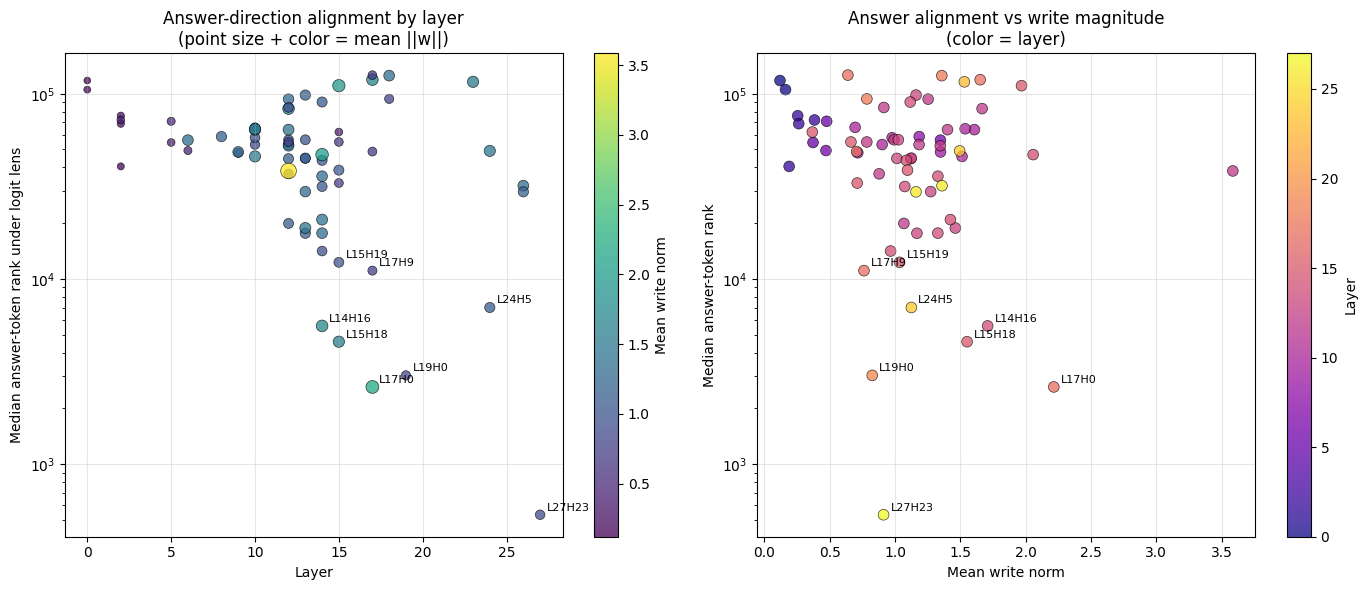

In [39]:
# Plot: layer vs answer rank, with norm as point size

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

layers = np.array([m['layer'] for m in head_metrics.values()])
ranks = np.array([m['median_rank'] for m in head_metrics.values()])
norms = np.array([m['mean_norm'] for m in head_metrics.values()])
head_keys = list(head_metrics.keys())

# Left: rank vs layer, point size = norm
ax = axes[0]
sc = ax.scatter(layers, ranks, s=20 + norms * 30, c=norms, cmap='viridis',
                alpha=0.75, edgecolors='black', linewidths=0.5)
ax.set_yscale('log')
ax.set_xlabel('Layer')
ax.set_ylabel('Median answer-token rank under logit lens')
ax.set_title('Answer-direction alignment by layer\n(point size + color = mean ||w||)')
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='Mean write norm')

# Annotate strongest heads (lowest rank)
top_idx = np.argsort(ranks)[:8]
for i in top_idx:
    l, h = head_keys[i]
    ax.annotate(f'L{l}H{h}', (layers[i], ranks[i]),
                xytext=(5, 3), textcoords='offset points', fontsize=8)

# Right: rank vs norm, colored by layer
ax = axes[1]
sc = ax.scatter(norms, ranks, s=60, c=layers, cmap='plasma', alpha=0.75,
                edgecolors='black', linewidths=0.5)
ax.set_yscale('log')
ax.set_xlabel('Mean write norm')
ax.set_ylabel('Median answer-token rank')
ax.set_title('Answer alignment vs write magnitude\n(color = layer)')
ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='Layer')

for i in top_idx:
    l, h = head_keys[i]
    ax.annotate(f'L{l}H{h}', (norms[i], ranks[i]),
                xytext=(5, 3), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

In [18]:
TARGET_HEADS = [(12, 20), (14, 12), (17, 0), (17, 9), (24, 4), (27, 23)]  # spread across layers
TOP_K_SINGULAR = 10  # how many singular pairs to inspect
TOP_K_TOKENS = 8     # how many decoded tokens per direction

W_U_np = model.W_U.detach().cpu().float().numpy()
W_U_t = model.W_U  # for ln_final + decode

def decode_direction(vec):
    """Logit lens on a single residual-stream direction."""
    vec_t = torch.tensor(vec, dtype=torch.float32, device=model.cfg.device)
    with torch.no_grad():
        normed = model.ln_final(vec_t.unsqueeze(0))
        logits = (normed @ W_U_t).squeeze().detach().cpu().float().numpy()
    top_k = np.argsort(-logits)[:TOP_K_TOKENS]
    return [model.to_string([int(t)]) for t in top_k]

for l, h in TARGET_HEADS:
    W_V = model.blocks[l].attn.W_V[h].detach().cpu().float().numpy()
    W_O = model.blocks[l].attn.W_O[h].detach().cpu().float().numpy()
    M = W_V @ W_O  # [d_model, d_model]
    
    # SVD: M = U @ diag(S) @ Vt
    # Right singular vectors (rows of Vt) = "input directions head reads"
    # Left singular vectors (columns of U) = "output directions head writes"
    U, S, Vt = np.linalg.svd(M, full_matrices=False)
    
    print(f'\n{"="*80}')
    print(f'L{l}H{h}  |  top {TOP_K_SINGULAR} singular pairs of W_V @ W_O')
    print(f'{"="*80}')
    print(f'Singular value spectrum: {S[:5].round(2)}... (rank ≤ {len(S)})')
    
    for k in range(TOP_K_SINGULAR):
        v_in = Vt[k]   # input direction (right singular vector)
        u_out = U[:, k]  # output direction (left singular vector)
        sigma = S[k]
        
        in_tokens = decode_direction(v_in)
        in_tokens_neg = decode_direction(-v_in)  # SVD signs are arbitrary
        out_tokens = decode_direction(u_out)
        out_tokens_neg = decode_direction(-u_out)
        
        print(f'\n  σ_{k} = {sigma:.2f}')
        print(f'    READS  +: {in_tokens}')
        print(f'    READS  -: {in_tokens_neg}')
        print(f'    WRITES +: {out_tokens}')
        print(f'    WRITES -: {out_tokens_neg}')


L12H20  |  top 10 singular pairs of W_V @ W_O
Singular value spectrum: [0.56 0.54 0.5  0.49 0.47]... (rank ≤ 3072)

  σ_0 = 0.56
    READS  +: ['rof', 'arest', 'chers', ' Stef', 'steen', 'owe', 'oste', 'aina']
    READS  -: [' intel', 'ucker', 'ige', ' Mond', '.setTag', ' Medal', ' mover', ' challenged']
    WRITES +: ['holding', 'олю', 'mort', '-packages', '-mort', '.createClass', 'Tpl', 'enet']
    WRITES -: ['kaar', ' Foam', 'dat', 'gars', '_SHARED', ' Tun', ' Hayes', 'imitives']

  σ_1 = 0.54
    READS  +: [' rom', 'oise', ' chim', ' Gre', 'Ing', 'phants', 'reads', ' tslint']
    READS  -: [' inferior', 'picker', ' vans', 'abolic', ' superior', ' Stevens', 'itters', 'actors']
    WRITES +: [' IMDb', ' pokus', ' Charg', ' Imper', 'charg', 'Caller', ' Intern', '.python']
    WRITES -: [' Om', ' convergence', ' ins', ' vac', ' infiltration', 'جب', ' flare', 'stinence']

  σ_2 = 0.50
    READS  +: ['imity', ' Tie', 'IFF', ' empathy', ' Ore', 'itere', ' catcher', ' Weiner']
    READS  

## How are outputs formed

In [35]:
from contextlib import nullcontext
from collections import defaultdict
import numpy as np

# --- Step 0: compute mean L0 residual at input token positions across all prompts ---
print('Computing mean input residual at L0...')
NAMES_L0 = lambda name: name == 'blocks.0.hook_resid_post'

input_residuals = []
for task_name, splits in tqdm(all_splits.items(), desc='mean'):
    for pdata in splits['icl_prompts'][:5]:
        prompt = pdata['prompt']
        tokens = model.to_tokens(prompt, prepend_bos=True)
        per_demo = find_per_demo_positions(model, prompt, pdata['demo_pairs'])
        input_positions = [d['separator_positions'][-1] - 1
                           for d in per_demo if d.get('separator_positions')]
        if not input_positions:
            continue
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=NAMES_L0)
        resid = cache['blocks.0.hook_resid_post'][0]
        for p in input_positions:
            input_residuals.append(resid[p].cpu().float().numpy())
        del cache
        torch.cuda.empty_cache()

mean_input_residual = np.mean(input_residuals, axis=0)
mean_input_residual_t = torch.tensor(mean_input_residual, dtype=torch.float32, device=model.cfg.device)
print(f'Mean input residual norm: {np.linalg.norm(mean_input_residual):.2f} (n={len(input_residuals)})')

# --- Replacement hook: use mean instead of zero ---
NAMES_IH = lambda name: ('hook_pattern' in name or 'hook_v' in name)

def make_mean_input_hook(input_positions):
    def hook_fn(resid, hook):
        for p in input_positions:
            resid[0, p] = mean_input_residual_t
        return resid
    return hook_fn

def collect_writes(ablate=False):
    writes = []
    tasks_out = []
    for task_name, splits in tqdm(all_splits.items(), desc='abl' if ablate else 'orig'):
        for pdata in splits['icl_prompts'][:5]:
            prompt = pdata['prompt']
            tokens = model.to_tokens(prompt, prepend_bos=True)
            last_pos = tokens.shape[1] - 1
            
            if ablate:
                per_demo = find_per_demo_positions(model, prompt, pdata['demo_pairs'])
                input_positions = [d['separator_positions'][-1] - 1
                                   for d in per_demo if d.get('separator_positions')]
                if not input_positions:
                    continue
                hooks = [(f'blocks.0.hook_resid_post', make_mean_input_hook(input_positions))]
                ctx = model.hooks(fwd_hooks=hooks)
            else:
                ctx = nullcontext()
            
            with torch.no_grad(), ctx:
                _, cache = model.run_with_cache(tokens, names_filter=NAMES_IH)
            
            total_write = np.zeros(model.cfg.d_model)
            for l, h in output_attending_heads:
                attn = cache[f'blocks.{l}.attn.hook_pattern'][0, h, last_pos].cpu().float().numpy()
                n_kv = cache[f'blocks.{l}.attn.hook_v'].shape[2]
                kv_h = h * n_kv // model.cfg.n_heads
                v = cache[f'blocks.{l}.attn.hook_v'][0, :, kv_h].cpu().float().numpy()
                z = (attn[:, None] * v).sum(axis=0)
                W_O = model.blocks[l].attn.W_O[h].detach().cpu().float().numpy()
                total_write += z @ W_O
            
            writes.append(total_write)
            tasks_out.append(task_name)
            del cache
            torch.cuda.empty_cache()
    
    return np.array(writes), np.array(tasks_out)

writes_orig, tasks_orig = collect_writes(ablate=False)
writes_abl, tasks_abl = collect_writes(ablate=True)

unique_tasks = sorted(set(tasks_orig))
task_vec_orig = {t: writes_orig[tasks_orig == t].mean(axis=0) for t in unique_tasks}
task_vec_abl = {t: writes_abl[tasks_abl == t].mean(axis=0) for t in unique_tasks}

for t in list(unique_tasks)[:3]:
    print(f'{t}: ||orig||={np.linalg.norm(task_vec_orig[t]):.2f}, '
          f'||abl||={np.linalg.norm(task_vec_abl[t]):.2f}, '
          f'cos={np.dot(task_vec_orig[t], task_vec_abl[t]) / (np.linalg.norm(task_vec_orig[t]) * np.linalg.norm(task_vec_abl[t])):.3f}')

Computing mean input residual at L0...


mean: 100%|██████████| 20/20 [00:05<00:00,  4.00it/s]


Mean input residual norm: 0.80 (n=1000)


abl: 100%|██████████| 20/20 [00:07<00:00,  2.52it/s]

knowledge/country_capital: ||orig||=9.49, ||abl||=9.39, cos=0.866
knowledge/football_player_position: ||orig||=12.98, ||abl||=11.40, cos=0.933
knowledge/location_continent: ||orig||=12.65, ||abl||=11.95, cos=0.945


In [36]:
INJECT_LAYER = 12

def make_injection_hook(write_vec, last_pos):
    write_t = torch.tensor(write_vec, dtype=torch.float32, device=model.cfg.device)
    def hook_fn(resid, hook):
        resid[0, last_pos] = resid[0, last_pos] + write_t
        return resid
    return hook_fn

n_zs = 0
n_orig = 0
n_abl = 0
n_total = 0

for task_name, splits in tqdm(all_splits.items(), desc='zero-shot eval'):
    if task_name not in task_vec_orig:
        continue
    eval_pairs = splits.get('eval_data', [])
    for eq in eval_pairs[:10]:
        zs_prompt = eq.get('zs_prompt')
        if zs_prompt is None:
            continue
        correct = eq['query_output']
        ans_tok = first_tok_id(' ' + correct, model)
        
        tokens = model.to_tokens(zs_prompt, prepend_bos=True)
        last_pos = tokens.shape[1] - 1
        
        # Baseline
        with torch.no_grad():
            pred = model(tokens)[0, last_pos].argmax().item()
        n_zs += (pred == ans_tok)
        
        # Inject orig
        hook = (f'blocks.{INJECT_LAYER}.hook_resid_post', make_injection_hook(task_vec_orig[task_name], last_pos))
        with torch.no_grad(), model.hooks(fwd_hooks=[hook]):
            pred = model(tokens)[0, last_pos].argmax().item()
        n_orig += (pred == ans_tok)
        
        # Inject ablated
        hook = (f'blocks.{INJECT_LAYER}.hook_resid_post', make_injection_hook(task_vec_abl[task_name], last_pos))
        with torch.no_grad(), model.hooks(fwd_hooks=[hook]):
            pred = model(tokens)[0, last_pos].argmax().item()
        n_abl += (pred == ans_tok)
        
        n_total += 1

print(f'\n=== Zero-shot recovery (n={n_total}) ===')
print(f'Zero-shot baseline:               {n_zs/n_total:.3f}')
print(f'Inject ORIG IH write:             {n_orig/n_total:.3f}')
print(f'Inject ABLATED-INPUT IH write:    {n_abl/n_total:.3f}')

zero-shot eval: 100%|██████████| 20/20 [00:23<00:00,  1.19s/it]


=== Zero-shot recovery (n=200) ===
Zero-shot baseline:               0.010
Inject ORIG IH write:             0.665
Inject ABLATED-INPUT IH write:    0.365


per-task eval: 100%|██████████| 20/20 [00:23<00:00,  1.19s/it]


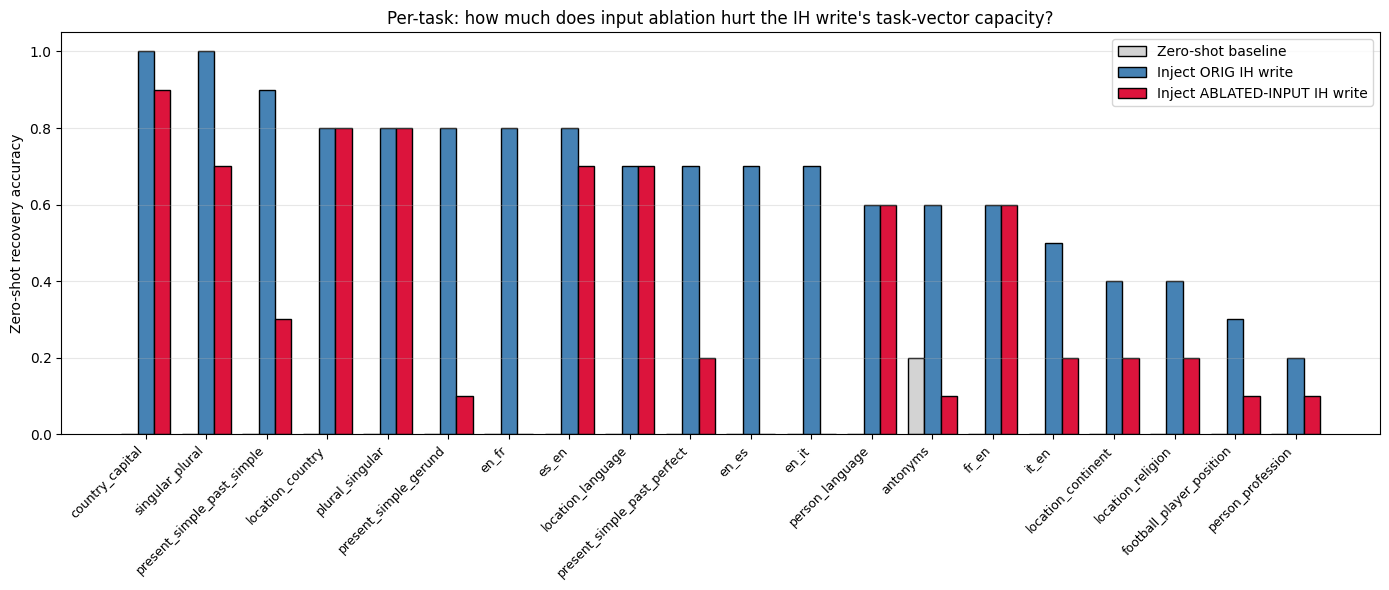


Task                                      Zero-shot     Orig    Ablated     Drop
------------------------------------------------------------------------------
translation/en_fr                              0.00     0.80       0.00    +0.80
linguistic/present_simple_gerund               0.00     0.80       0.10    +0.70
translation/en_es                              0.00     0.70       0.00    +0.70
translation/en_it                              0.00     0.70       0.00    +0.70
linguistic/present_simple_past_simple          0.00     0.90       0.30    +0.60
linguistic/present_simple_past_perfect         0.00     0.70       0.20    +0.50
linguistic/antonyms                            0.20     0.60       0.10    +0.50
linguistic/singular_plural                     0.00     1.00       0.70    +0.30
translation/it_en                              0.00     0.50       0.20    +0.30
knowledge/location_continent                   0.00     0.40       0.20    +0.20
knowledge/location_religion  

In [37]:
import matplotlib.pyplot as plt

# Per-task accuracy
per_task_zs = defaultdict(int)
per_task_orig = defaultdict(int)
per_task_abl = defaultdict(int)
per_task_n = defaultdict(int)

for task_name, splits in tqdm(all_splits.items(), desc='per-task eval'):
    if task_name not in task_vec_orig:
        continue
    eval_pairs = splits.get('eval_data', [])
    for eq in eval_pairs[:10]:
        zs_prompt = eq.get('zs_prompt')
        if zs_prompt is None:
            continue
        correct = eq['query_output']
        ans_tok = first_tok_id(' ' + correct, model)
        
        tokens = model.to_tokens(zs_prompt, prepend_bos=True)
        last_pos = tokens.shape[1] - 1
        
        with torch.no_grad():
            pred = model(tokens)[0, last_pos].argmax().item()
        per_task_zs[task_name] += (pred == ans_tok)
        
        hook = (f'blocks.{INJECT_LAYER}.hook_resid_post', make_injection_hook(task_vec_orig[task_name], last_pos))
        with torch.no_grad(), model.hooks(fwd_hooks=[hook]):
            pred = model(tokens)[0, last_pos].argmax().item()
        per_task_orig[task_name] += (pred == ans_tok)
        
        hook = (f'blocks.{INJECT_LAYER}.hook_resid_post', make_injection_hook(task_vec_abl[task_name], last_pos))
        with torch.no_grad(), model.hooks(fwd_hooks=[hook]):
            pred = model(tokens)[0, last_pos].argmax().item()
        per_task_abl[task_name] += (pred == ans_tok)
        
        per_task_n[task_name] += 1

# Sort tasks by orig recovery (descending)
tasks_sorted = sorted([t for t in per_task_n if per_task_n[t] > 0],
                      key=lambda t: -per_task_orig[t] / per_task_n[t])

zs_acc = [per_task_zs[t] / per_task_n[t] for t in tasks_sorted]
orig_acc = [per_task_orig[t] / per_task_n[t] for t in tasks_sorted]
abl_acc = [per_task_abl[t] / per_task_n[t] for t in tasks_sorted]
labels = [t.split('/')[-1] for t in tasks_sorted]

x = np.arange(len(tasks_sorted))
width = 0.27

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, zs_acc, width, label='Zero-shot baseline', color='lightgray', edgecolor='black')
ax.bar(x, orig_acc, width, label='Inject ORIG IH write', color='steelblue', edgecolor='black')
ax.bar(x + width, abl_acc, width, label='Inject ABLATED-INPUT IH write', color='crimson', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Zero-shot recovery accuracy')
ax.set_title('Per-task: how much does input ablation hurt the IH write\'s task-vector capacity?')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Print table sorted by drop
print(f'\n{"Task":<40} {"Zero-shot":>10} {"Orig":>8} {"Ablated":>10} {"Drop":>8}')
print('-' * 78)
for t in sorted(tasks_sorted, key=lambda t: -(per_task_orig[t] - per_task_abl[t]) / max(per_task_n[t], 1)):
    n = per_task_n[t]
    print(f'{t:<40} {per_task_zs[t]/n:>10.2f} {per_task_orig[t]/n:>8.2f} {per_task_abl[t]/n:>10.2f} {(per_task_orig[t]-per_task_abl[t])/n:>+8.2f}')

In [38]:
# Collect per-head writes under mean ablation (need this — only orig was collected before)

NAMES_IH = lambda name: ('hook_pattern' in name or 'hook_v' in name)

per_head_writes_abl = defaultdict(list)
prompt_tasks_abl = []

for task_name, splits in tqdm(all_splits.items(), desc='collecting abl per-head'):
    for pdata in splits['icl_prompts'][:5]:
        prompt = pdata['prompt']
        tokens = model.to_tokens(prompt, prepend_bos=True)
        last_pos = tokens.shape[1] - 1
        per_demo = find_per_demo_positions(model, prompt, pdata['demo_pairs'])
        input_positions = [d['separator_positions'][-1] - 1
                           for d in per_demo if d.get('separator_positions')]
        if not input_positions:
            continue
        
        hooks = [(f'blocks.0.hook_resid_post', make_mean_input_hook(input_positions))]
        with torch.no_grad(), model.hooks(fwd_hooks=hooks):
            _, cache = model.run_with_cache(tokens, names_filter=NAMES_IH)
        
        for l, h in output_attending_heads:
            attn = cache[f'blocks.{l}.attn.hook_pattern'][0, h, last_pos].cpu().float().numpy()
            n_kv = cache[f'blocks.{l}.attn.hook_v'].shape[2]
            kv_h = h * n_kv // model.cfg.n_heads
            v = cache[f'blocks.{l}.attn.hook_v'][0, :, kv_h].cpu().float().numpy()
            z = (attn[:, None] * v).sum(axis=0)
            W_O = model.blocks[l].attn.W_O[h].detach().cpu().float().numpy()
            per_head_writes_abl[(l, h)].append(z @ W_O)
        
        prompt_tasks_abl.append(task_name)
        del cache
        torch.cuda.empty_cache()

prompt_tasks_abl = np.array(prompt_tasks_abl)
print(f'Collected ablated per-head writes for {len(prompt_tasks_abl)} prompts')

collecting abl per-head: 100%|██████████| 20/20 [00:07<00:00,  2.53it/s]

Collected ablated per-head writes for 100 prompts


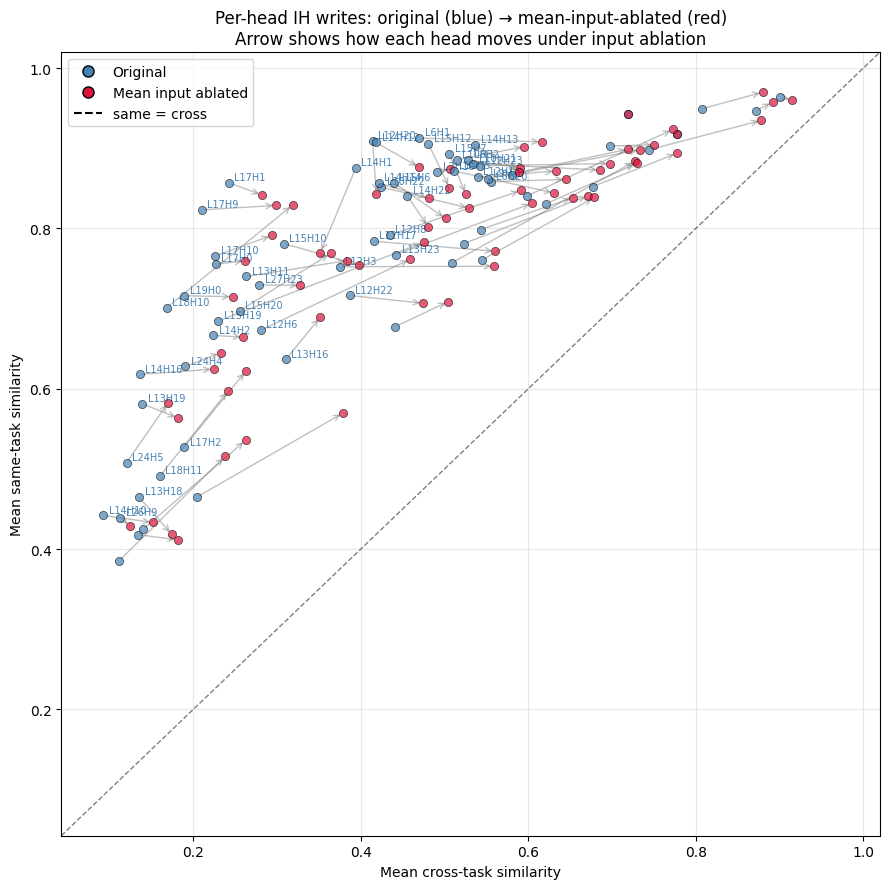


Top 15 heads by drop in same-task similarity (most affected by input ablation):
Head        Same orig   Same abl     Drop  Cross orig   Cross abl
-----------------------------------------------------------------
L14H1           0.875      0.770   +0.105       0.394       0.352
L12H20          0.909      0.843   +0.066       0.414       0.419
L15H12          0.906      0.851   +0.055       0.481       0.506
L15H7           0.893      0.843   +0.050       0.506       0.526
L13H18          0.465      0.419   +0.046       0.135       0.174
L15H6           0.857      0.813   +0.045       0.439       0.501
L14H22          0.840      0.802   +0.038       0.456       0.480
L14H13          0.904      0.870   +0.034       0.537       0.589
L14H12          0.907      0.876   +0.031       0.418       0.470
L14H5           0.872      0.844   +0.027       0.511       0.631
L15H10          0.781      0.754   +0.027       0.308       0.399
L10H22          0.852      0.825   +0.026       0.425       0

In [39]:
# Compute per-head stats for both conditions, plot as arrows orig -> ablated

import matplotlib.pyplot as plt

def head_stats_for(per_head_writes_dict, task_labels):
    stats = {}
    for (l, h), writes in per_head_writes_dict.items():
        W = np.array(writes)
        norms = np.linalg.norm(W, axis=1, keepdims=True)
        Wn = W / (norms + 1e-12)
        sims = Wn @ Wn.T
        n = len(W)
        same, cross = [], []
        for i in range(n):
            for j in range(i+1, n):
                (same if task_labels[i] == task_labels[j] else cross).append(sims[i, j])
        stats[(l, h)] = (np.mean(same), np.mean(cross))
    return stats

stats_orig = head_stats_for(per_head_writes, prompt_tasks)
stats_abl = head_stats_for(per_head_writes_abl, prompt_tasks_abl)

fig, ax = plt.subplots(figsize=(9, 9))

for (l, h) in sorted(stats_orig.keys()):
    if (l, h) not in stats_abl: continue
    s_o, c_o = stats_orig[(l, h)]
    s_a, c_a = stats_abl[(l, h)]
    
    # Arrow from orig position to ablated position
    ax.annotate('', xy=(c_a, s_a), xytext=(c_o, s_o),
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, lw=1))
    
    ax.scatter(c_o, s_o, c='steelblue', s=35, alpha=0.7, edgecolors='black', linewidths=0.5, zorder=5)
    ax.scatter(c_a, s_a, c='crimson', s=35, alpha=0.7, edgecolors='black', linewidths=0.5, zorder=5)
    
    if (s_o - c_o) > 0.3 or (s_o - s_a) > 0.15:  # label strong or strongly-affected heads
        ax.annotate(f'L{l}H{h}', (c_o, s_o),
                    xytext=(4, 2), textcoords='offset points', fontsize=7, color='steelblue')

# Diagonal: same == cross
all_x = [c for (s, c) in list(stats_orig.values()) + list(stats_abl.values())]
all_y = [s for (s, c) in list(stats_orig.values()) + list(stats_abl.values())]
lo, hi = min(min(all_x), min(all_y)) - 0.05, max(max(all_x), max(all_y)) + 0.05
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.5)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)

ax.set_xlabel('Mean cross-task similarity')
ax.set_ylabel('Mean same-task similarity')
ax.set_title('Per-head IH writes: original (blue) → mean-input-ablated (red)\n'
             'Arrow shows how each head moves under input ablation')

# Custom legend
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', mfc='steelblue', mec='black', ms=8, label='Original'),
    Line2D([0],[0], marker='o', color='w', mfc='crimson', mec='black', ms=8, label='Mean input ablated'),
    Line2D([0],[0], color='black', ls='--', label='same = cross'),
])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print: heads that drop most in same-task similarity (most affected by input ablation)
print(f'\nTop 15 heads by drop in same-task similarity (most affected by input ablation):')
print(f'{"Head":<10} {"Same orig":>10} {"Same abl":>10} {"Drop":>8} {"Cross orig":>11} {"Cross abl":>11}')
print('-' * 65)
diffs = [(lh, stats_orig[lh][0] - stats_abl[lh][0], stats_orig[lh], stats_abl[lh])
         for lh in stats_orig if lh in stats_abl]
for (l, h), drop, (so, co), (sa, ca) in sorted(diffs, key=lambda x: -x[1])[:15]:
    print(f'L{l}H{h:<6} {so:>10.3f} {sa:>10.3f} {drop:>+8.3f} {co:>11.3f} {ca:>11.3f}')